In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import math  
import seaborn as sns 
import requests, re
from bs4 import BeautifulSoup
from random import randint
import time
import random
import numpy as np
import matplotlib as mpl
import statsmodels.api as sm
import python_weather
import asyncio
import os
import json
import datetime


In [2]:
sales_data = pd.read_csv("Tacombi Raw Data.csv")
promos2025 = pd.read_csv("2025 Campaigns.csv")


C:\Users\willi\AppData\Local\Temp\ipykernel_5992\3907605643.py:1: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_data = pd.read_csv("Tacombi Raw Data.csv")


## Section 1: Data Cleaning

Majority of the cleaning is reused from Tacombi Project file.

In [3]:
#Drop unnecessary cols
sales_data["Full Price"] = sales_data["No Promo"]
sales_data = sales_data[[
    'Sales (excl. tax)', 'Order Date', 'Order Day',
    'Promo', 'Full Price', 'Day Part', 'Store Name', 
    'Dining Mode', 'Order Status', 'Customer Uber-Membership Status',
    'Offers on items (incl. tax)', 'Tax On Offers on items'
    ]]



promos2025 = promos2025[['Sales (USD)', 'New customers', 'Orders', 'Start date',
 'End date',  'Stores', 'Offer type', 'Status', 'Audience',]]



sales_data["Order Date"] = pd.to_datetime(sales_data["Order Date"], origin = "1899-12-30", unit = "D")
sales_data["Year"] = sales_data["Order Date"].dt.year
sales_data["Month"] = sales_data["Order Date"].dt.month
sales_data["DayOfWeek"] = sales_data["Order Date"].dt.day_name()

month_map = {
    "ene": "jan", "feb": "feb", "mar": "mar", "abr": "apr", "may": "may",
    "jun": "jun", "jul": "jul", "ago": "aug", "sep": "sep", "oct": "oct",
    "nov": "nov", "dic": "dec"
    
}

promos2025["Start date"] = promos2025["Start date"].astype(str).replace(month_map, regex = True)
promos2025["End date"] = promos2025["End date"].astype(str).replace(month_map, regex = True)

promos2025["Start date"] = (pd.to_datetime(promos2025["Start date"], errors = "coerce", dayfirst = True).
                                 fillna(pd.to_datetime(pd.to_numeric(promos2025["Start date"], errors = "coerce"), origin = "1899-12-30", unit = "D")))

promos2025["End date"] = (pd.to_datetime(promos2025["End date"], errors = "coerce", dayfirst = True).
                               fillna(pd.to_datetime(pd.to_numeric(promos2025["End date"], errors = "coerce"), origin = "1899-12-30", unit = "D")))

#Filter for 2025 orders
sales_data = sales_data[sales_data["Order Date"].dt.year == 2025]

#Filter for Completed Orders
sales_data = sales_data[sales_data["Order Status"] == "Completed"]

# Remove Tacombi - from names
sales_data["Store Name"] = (
    sales_data["Store Name"]
    .str.split("-", n=1)
    .str[1]
    .str.strip()
)



In [4]:
# Get list of unique campaign offer types
offer_types = promos2025['Offer type'].dropna().unique()

# Initialize binary columns to 0
for offer in offer_types:
    sales_data[offer] = 0

# Assign campaign windows
for offer in offer_types:

    # Pull all date windows for this campaign type
    windows = promos2025.loc[promos2025['Offer type'] == offer,
                                  ['Start date', 'End date']]

    # For each window, mark the rows in sales_data
    for _, w in windows.iterrows():
        start = w['Start date']
        end = w['End date']

        mask = (sales_data['Order Date'] >= start) & (sales_data['Order Date'] <= end)

        sales_data.loc[mask, offer] = 1

# --- Define campaign groups ---
restrictive_campaigns = [
    "Buy 1, Get 1 Free",
    "Buy 1, get a free item",
    "Save on Menu Items"
]

non_restrictive_campaigns = [
    "25% off",
    "25% off, up to $35 ",
    "30% off",
    "30% off, up to $35 ",
    "40% off, up to $30 ",
    "Spend 30, Save 12",
    "Spend 30, Save 8",
    "Spend 35, Save 7",
    "Spend 35, Save 10",
    "Spend 35, Save 8",
    "Spend 40, Save 10",
    "Spend 40, Save 11",
    "Spend 45, Save 12"
]

non_restrictive_campaigns_spend_minimum = [
    "25% off, up to $35 ",
    "30% off, up to $35 ",
    "40% off, up to $30 ",
    "Spend 30, Save 12",
    "Spend 30, Save 8",
    "Spend 35, Save 7",
    "Spend 35, Save 10",
    "Spend 35, Save 8",
    "Spend 40, Save 10",
    "Spend 40, Save 11",
    "Spend 45, Save 12"
]

non_restrictive_campaigns_no_spend_minimum = [
    "25% off",
    "30% off"
]

# --- Ensure missing columns are treated as zero ---
for col in restrictive_campaigns + non_restrictive_campaigns:
    if col not in sales_data.columns:
        sales_data[col] = 0

# --- Create Restrictive flag ---
sales_data["Restrictive"] = (
    sales_data[restrictive_campaigns].sum(axis=1) > 0
).astype(int)

# --- Create Non-Restrictive flag ---
sales_data["Non-Restrictive"] = (
    sales_data[non_restrictive_campaigns].sum(axis=1) > 0
).astype(int)

# --- Create Non-Restrictive Spend Minimum flag ---
sales_data["Non-Restrictive with Spend Minimum"] = (
    sales_data[non_restrictive_campaigns_spend_minimum].sum(axis=1) > 0
).astype(int)

# --- Create Non-Restrictive no Spend Minimum flag ---
sales_data["Non-Restrictive with no Spend Minimum"] = (
    sales_data[non_restrictive_campaigns_no_spend_minimum].sum(axis=1) > 0
).astype(int)

# ---- Classification Column ----
# Assumes you already created the Restrictive and Non-Restrictive binary columns
sales_data['Both'] = ((sales_data['Restrictive'] == 1) & 
                      (sales_data['Non-Restrictive'] == 1)).astype(int)

def classify_campaign(row):
    if row['Both'] == 1:
        return "Both"
    elif row['Restrictive'] == 1:
        return "Restrictive"
    elif (row['Non-Restrictive'] == 1 or 
          row['Non-Restrictive with Spend Minimum'] == 1 or 
          row['Non-Restrictive with no Spend Minimum'] == 1):
        return "Non-Restrictive"
    else:
        return "None"

sales_data['Campaign Type'] = sales_data.apply(classify_campaign, axis=1)

In [5]:
sales_data['Campaign Type'].value_counts()

Campaign Type
Both           159767
None            28254
Restrictive     19272
Name: count, dtype: int64

In [6]:

states = {
    "UWS": "New York",
    "Williamsburg": "New York",
    "Bleecker": "New York",
    "Flatiron": "New York",
    "Westbury": "New York",
    "Forest Hills": "New York",
    "Empire": "New York",
    "Nolita": "New York",
    "LIC": "New York",
    "Fort Greene": "New York",
    "UES": "New York",
    "Financial District": "New York",
    "Westport": "Connecticut",

    "Wicker Park": "Illinois",
    "Fulton Market": "Illinois",
    "Arlington": "Virginia",
    "Design District": "Florida",
    "Brickell": "Florida",
    "Bethesda": "Maryland",
}

#Add state col
sales_data["State"] = sales_data["Store Name"].map(states)

#Formulas
sales_data["Net Promo"] = abs(sales_data["Offers on items (incl. tax)"]) - abs(sales_data["Tax On Offers on items"])
sales_data["Promo %"] = sales_data["Net Promo"] / sales_data["Sales (excl. tax)"]
sales_data["Payout"] = sales_data["Sales (excl. tax)"] - sales_data["Net Promo"]
sales_data["Margin %"] = sales_data["Payout"] / sales_data["Sales (excl. tax)"]


## Seaborn Setup

In [7]:
palette = {
    "Restrictive": "#D62728",   #red
    "Non-Restrictive": "#2CA02C",  #green
    "Both": "#FFBF00",               #yellow
    "Full Price": "#1F77B4"            # blue
}

sns.set_theme(
    style="whitegrid",
    context="talk",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False
    }
)


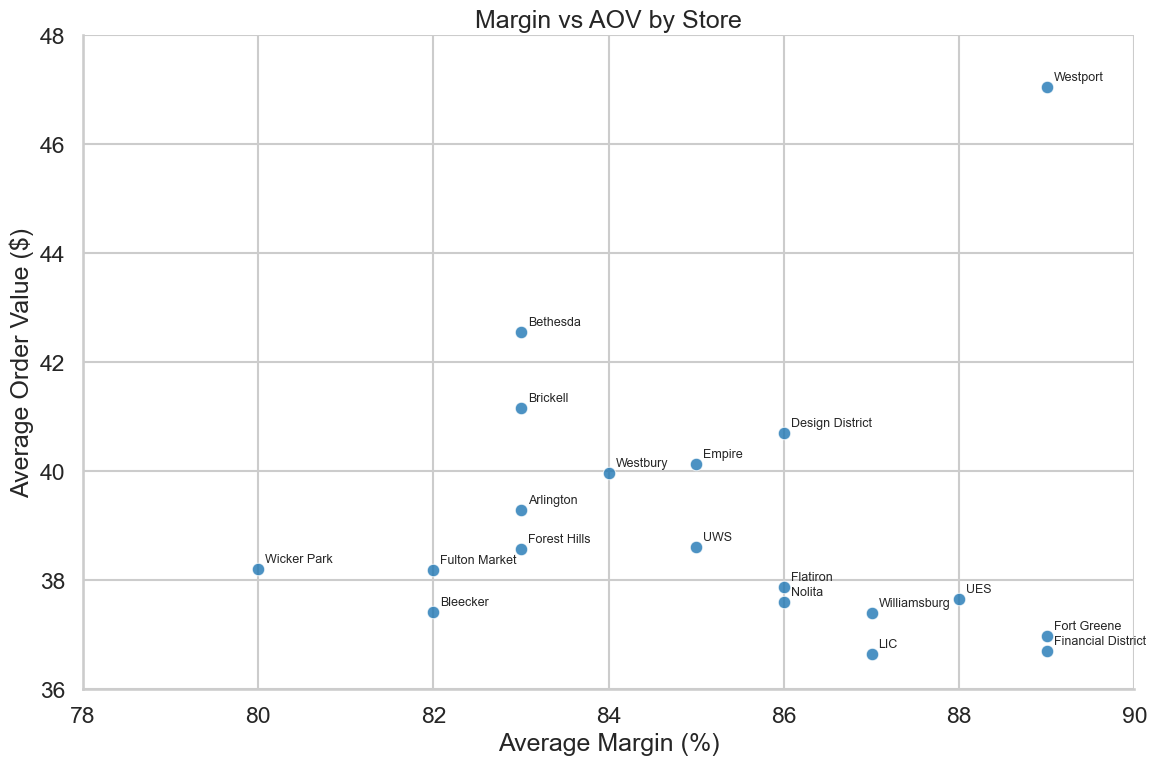

In [8]:
store_metrics = (
    sales_data
    .groupby("Store Name", as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean"),
    )
)

store_metrics[["aov", "avg_margin"]] = store_metrics[["aov", "avg_margin"]].round(2)
store_metrics["avg_margin_pct"] = store_metrics["avg_margin"] * 100

plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=store_metrics,
    x="avg_margin_pct",
    y="aov",
    color = "#1F77B4",
    alpha=0.8
)

for i, row in store_metrics.iterrows():
    ax.annotate(
        row["Store Name"],
        (row["avg_margin_pct"], row["aov"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )
    
    

plt.title("Margin vs AOV by Store")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")
plt.xlim(xmin=78, xmax = 90)
plt.ylim(ymin=36, ymax = 48)
plt.tight_layout()
plt.show()

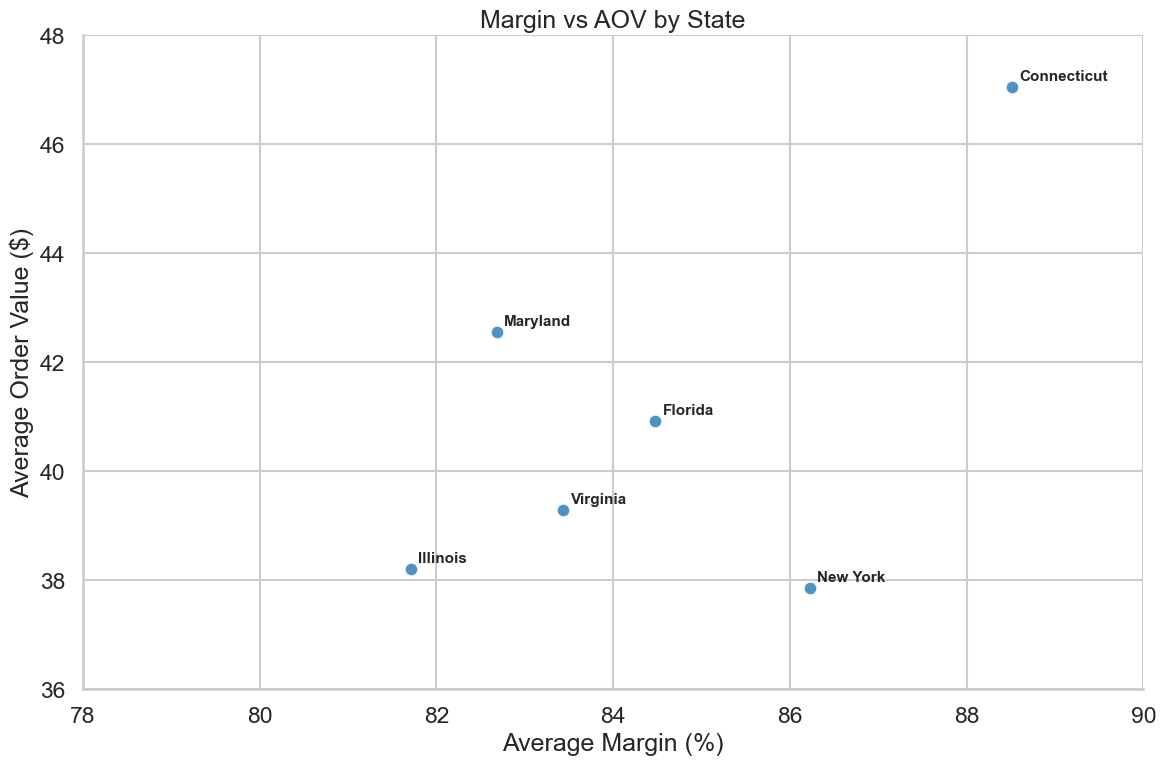

In [9]:
state_metrics = (
    sales_data
    .groupby("State", as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean"),
        orders=("Sales (excl. tax)", "count")
    )
)


state_metrics["avg_margin_pct"] = state_metrics["avg_margin"] * 100
state_metrics["aov"] = state_metrics["aov"].round(2)

plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=state_metrics,
    x="avg_margin_pct",
    y="aov",
    color="#1F77B4",
    alpha=0.8
)


for i, row in state_metrics.iterrows():
    ax.annotate(
        row["State"],
        (row["avg_margin_pct"], row["aov"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Margin vs AOV by State")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")
plt.xlim(xmin=78, xmax=90)
plt.ylim(ymin=36, ymax=48)
plt.tight_layout()
plt.show()

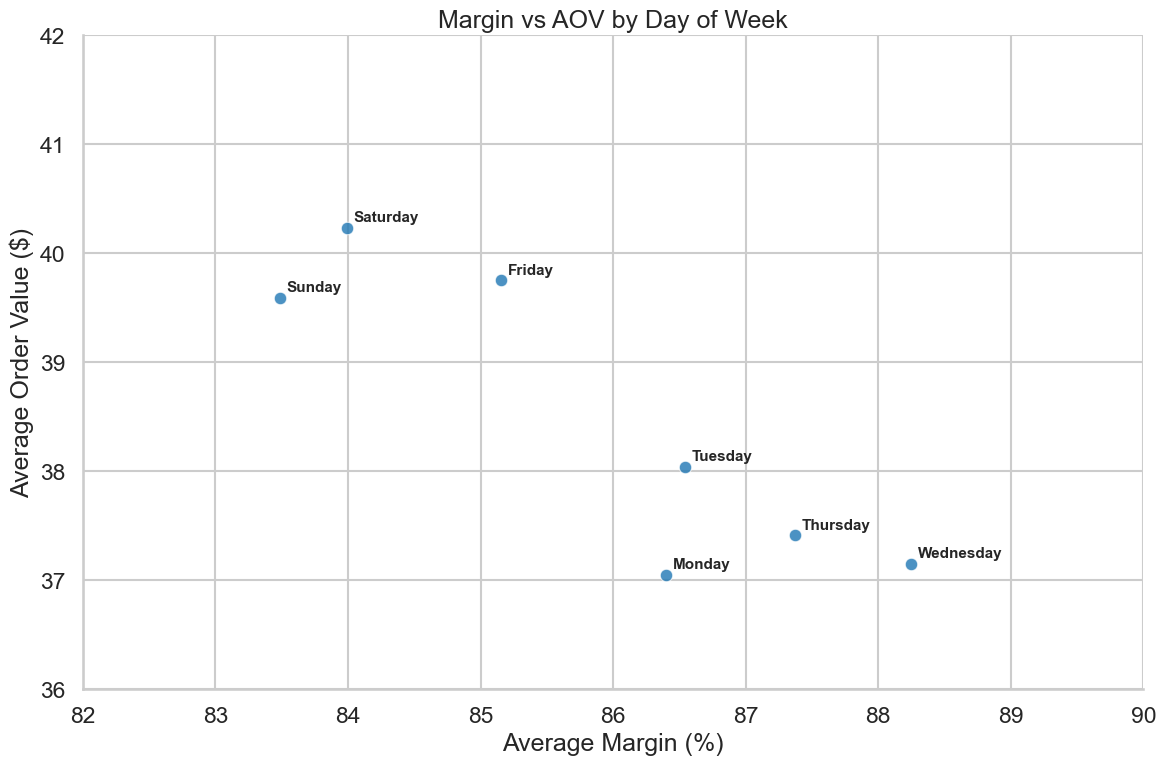

In [10]:
day_metrics = (
    sales_data
    .groupby("DayOfWeek", as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean"),
        orders=("Sales (excl. tax)", "count")
    )
)


day_metrics["avg_margin_pct"] = day_metrics["avg_margin"] * 100
day_metrics["aov"] = day_metrics["aov"].round(2)

plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=day_metrics,
    x="avg_margin_pct",
    y="aov",
    color="#1F77B4",    #blue
    alpha=0.8
)

for _, row in day_metrics.iterrows():
    ax.annotate(
        row["DayOfWeek"],
        (row["avg_margin_pct"], row["aov"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Margin vs AOV by Day of Week")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")
plt.xlim(xmin=82, xmax=90)
plt.ylim(ymin=36, ymax=42)
plt.tight_layout()
plt.show()

In [11]:
sales_data["Campaign Type"].unique()

array(['None', 'Restrictive', 'Both'], dtype=object)

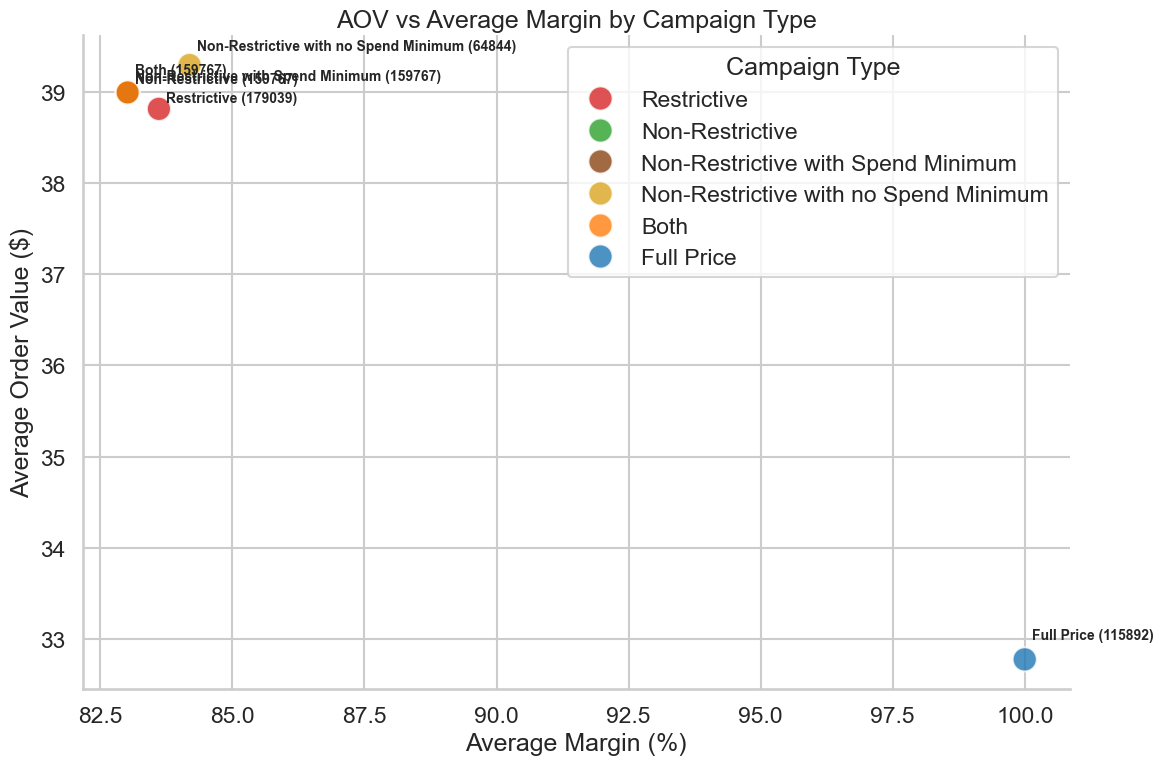

In [12]:
categories = [
    "Restrictive",
    "Non-Restrictive",
    "Non-Restrictive with Spend Minimum",
    "Non-Restrictive with no Spend Minimum",
    "Both",
    "Full Price"
]

# Prepare a dataframe where each row is a flag applied to the order
flag_metrics = []

for cat in categories:
    temp = sales_data[sales_data[cat] == 1]
    flag_metrics.append({
        "Campaign Type": cat,
        "aov": temp["Sales (excl. tax)"].mean(),
        "avg_margin_pct": temp["Margin %"].mean() * 100,
        "orders": temp.shape[0]
    })

campaign_metrics = pd.DataFrame(flag_metrics)
campaign_metrics["aov"] = campaign_metrics["aov"].round(2)

palette = {
    "Restrictive": "#D62728",
    "Non-Restrictive": "#2CA02C",
    "Non-Restrictive with Spend Minimum": "#8B4513",
    "Non-Restrictive with no Spend Minimum": "#DAA520",
    "Both": "#FF7F0E",
    "Full Price": "#1F77B4"
}

plt.figure(figsize=(12, 8))
ax = sns.scatterplot(
    data=campaign_metrics,
    x="avg_margin_pct",
    y="aov",
    hue="Campaign Type",
    palette=palette,
    s=300,
    alpha=0.8
)

# Add labels with number of orders appended
for i, row in campaign_metrics.iterrows():
    label = f"{row['Campaign Type']} ({row['orders']})"  # append orders
    # offset each label slightly based on index to reduce overlap
    ax.annotate(
        label,
        (row["avg_margin_pct"], row["aov"]),
        xytext=(5, 5 + i*2),  # vertical offset
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

plt.title("AOV vs Average Margin by Campaign Type")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")

plt.tight_layout()
plt.show()

In [13]:
sales_data[[
    "Non-Restrictive",
    "Non-Restrictive with Spend Minimum",
    "Non-Restrictive with no Spend Minimum"
]].sum()

Non-Restrictive                          159767
Non-Restrictive with Spend Minimum       159767
Non-Restrictive with no Spend Minimum     64844
dtype: int64

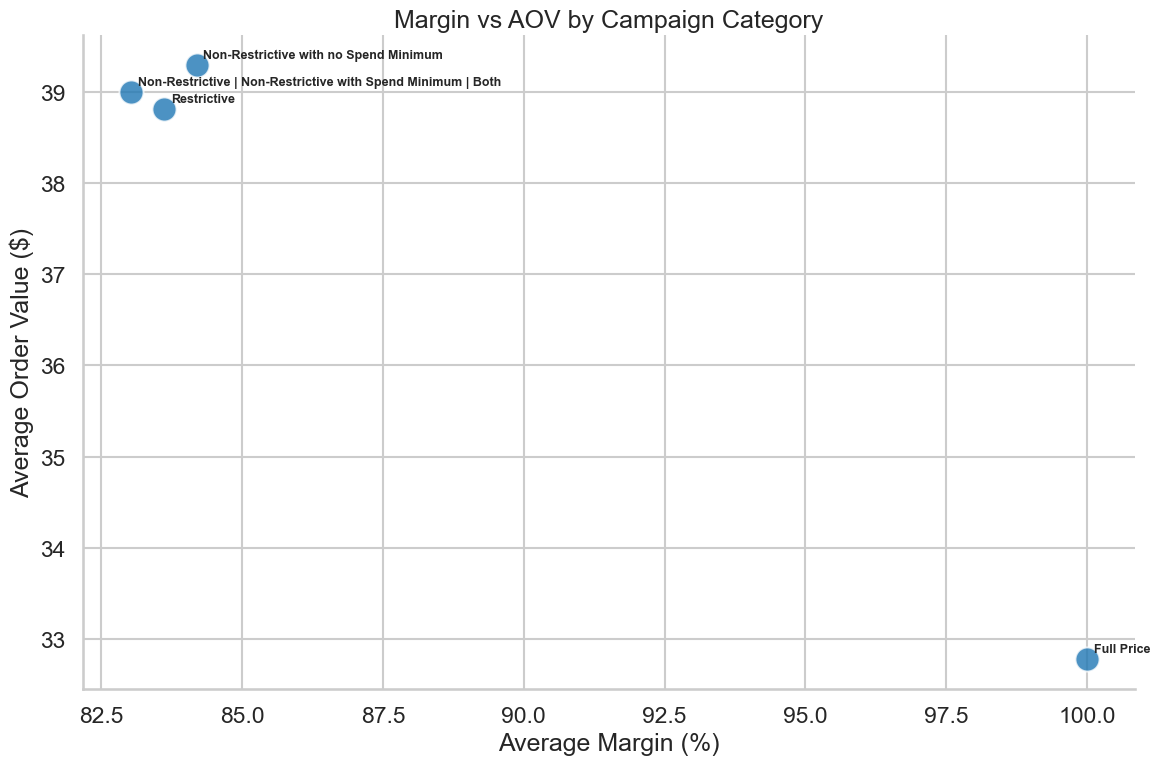

In [14]:
categories = [
    "Restrictive",
    "Non-Restrictive",
    "Non-Restrictive with Spend Minimum",
    "Non-Restrictive with no Spend Minimum",
    "Both",
    "Full Price"
]

# Collect metrics per category
category_metrics = []

for cat in categories:
    df = sales_data[sales_data[cat] == 1]
    category_metrics.append({
        "Category": cat,
        "aov": df["Sales (excl. tax)"].mean(),
        "avg_margin_pct": df["Margin %"].mean() * 100,
        "orders": df.shape[0]
    })

category_metrics = pd.DataFrame(category_metrics)
category_metrics["aov_r"] = category_metrics["aov"].round(2)
category_metrics["avg_margin_pct_r"] = category_metrics["avg_margin_pct"].round(2)

# Group by rounded values and concatenate labels for overlapping points
grouped = (
    category_metrics
    .groupby(["avg_margin_pct_r", "aov_r"])
    .agg({
        "Category": lambda x: " | ".join(x),  # concatenate overlapping category names
        "orders": "sum"
    })
    .reset_index()
)

# Palette
palette = {
    "Restrictive": "#D62728",
    "Non-Restrictive": "#2CA02C",
    "Non-Restrictive with Spend Minimum": "#8B4513",
    "Non-Restrictive with no Spend Minimum": "#DAA520",
    "Both": "#FF7F0E",
    "Full Price": "#1F77B4"
}

plt.figure(figsize=(12, 8))
ax = sns.scatterplot(
    data=grouped,
    x="avg_margin_pct_r",
    y="aov_r",
    s=300,
    color="#1F77B4",  
    alpha=0.8
)

# Annotate concatenated labels
for _, row in grouped.iterrows():
    ax.annotate(
        row["Category"],
        (row["avg_margin_pct_r"], row["aov_r"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Margin vs AOV by Campaign Category")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")
plt.tight_layout()
plt.show()

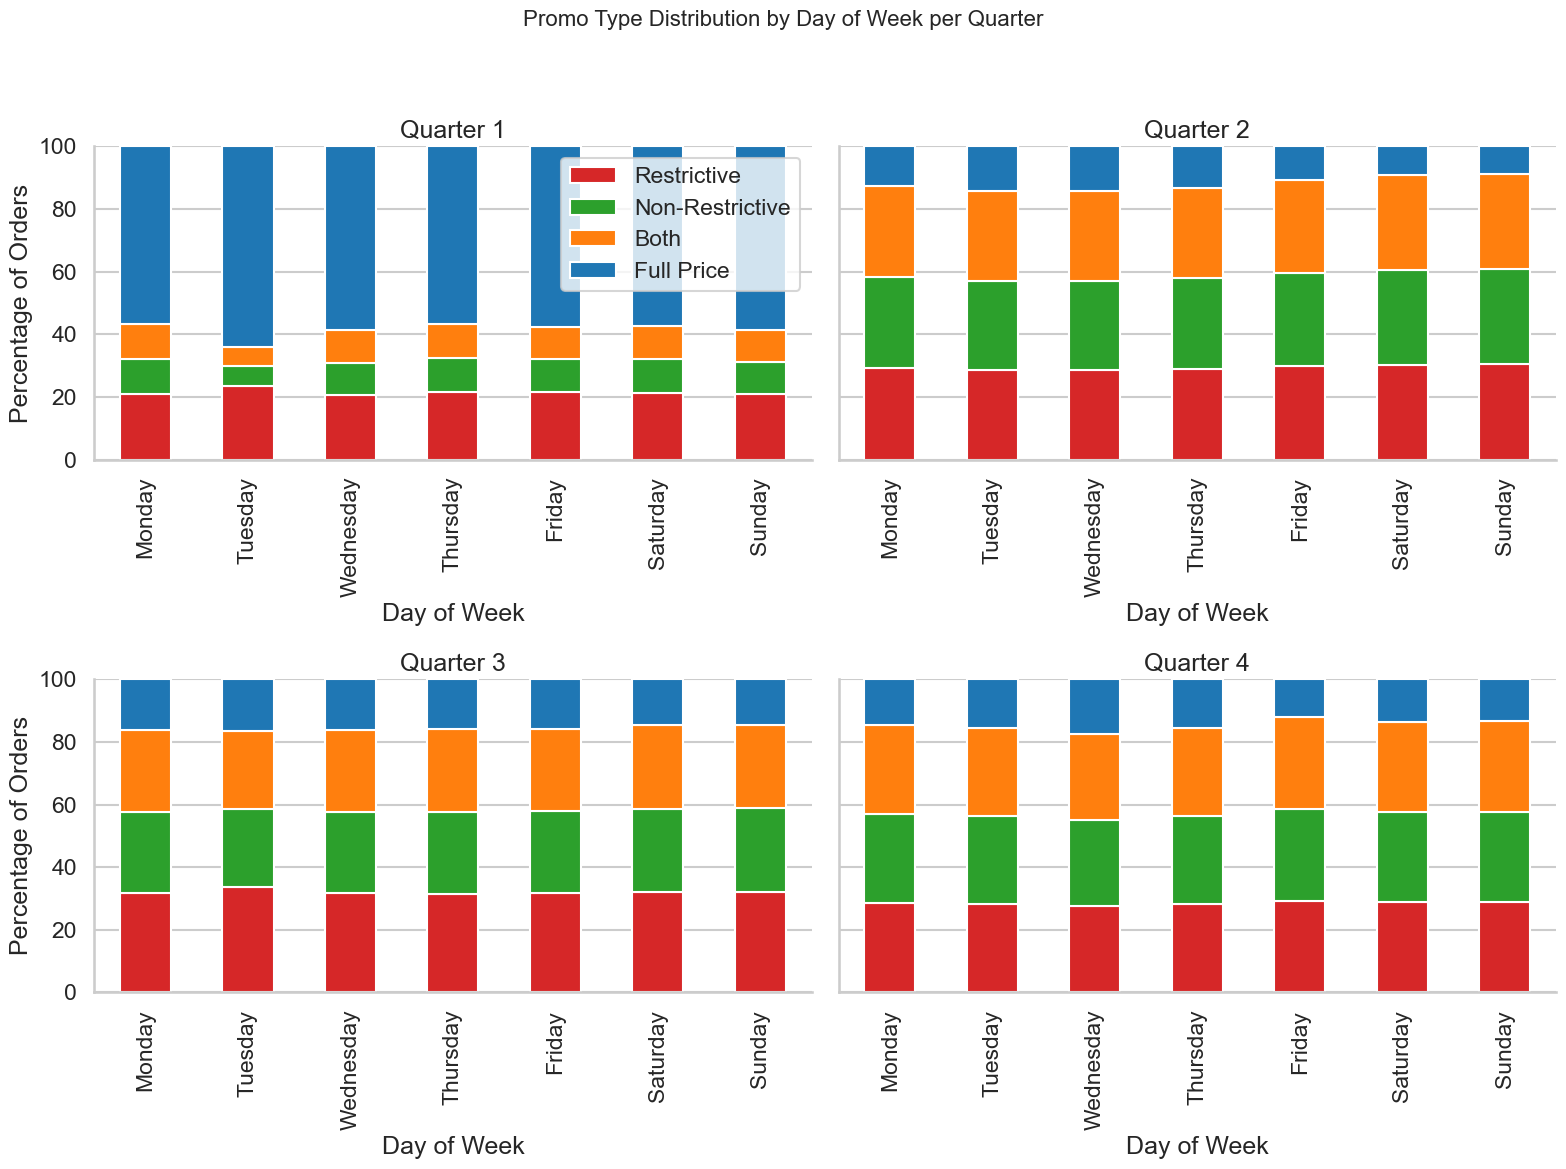

In [15]:
sales_data["Quarter"] = ((sales_data["Month"] - 1) // 3 + 1).astype(int)

promo_types = ["Restrictive", "Non-Restrictive", "Both", "Full Price"]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

quarter_data = {}

for q in range(1, 5):
    df_q = sales_data[sales_data["Quarter"] == q]
    daily_counts = df_q.groupby("DayOfWeek")[promo_types].sum()
    daily_totals = daily_counts.sum(axis=1)
    daily_pct = daily_counts.divide(daily_totals, axis=0) * 100
    daily_pct = daily_pct.reindex(day_order)  
    
    quarter_data[q] = daily_pct

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

palette = {
    "Restrictive": "#D62728",       # red
    "Non-Restrictive": "#2CA02C",   # green
    "Both": "#FF7F0E",               # orange
    "Full Price": "#1F77B4"            # blue
}

for i, q in enumerate(range(1, 5)):
    ax = axes[i]
    quarter_data[q].plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[palette[col] for col in quarter_data[q].columns],
        legend=(i==0) 
    )
    ax.set_title(f"Quarter {q}")
    ax.set_ylabel("Percentage of Orders")
    ax.set_xlabel("Day of Week")
    ax.set_ylim(0, 100)

plt.suptitle("Promo Type Distribution by Day of Week per Quarter", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

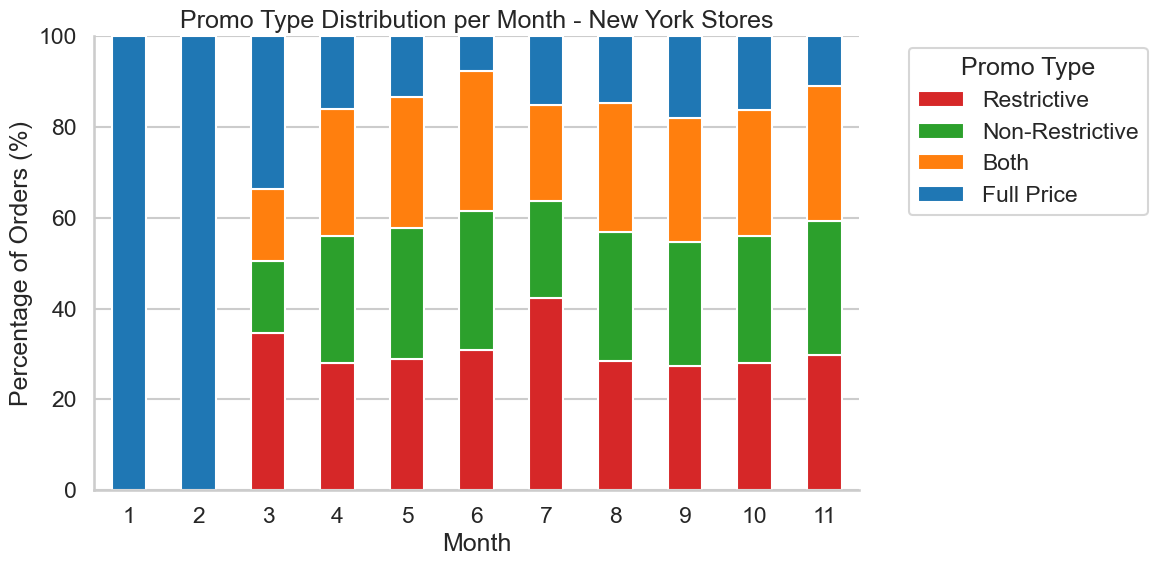

In [16]:
ny_data = sales_data[sales_data["State"] == "New York"]
promo_types = ["Restrictive", "Non-Restrictive", "Both", "Full Price"]
monthly_counts = ny_data.groupby("Month")[promo_types].sum()
monthly_pct = monthly_counts.div(monthly_counts.sum(axis=1), axis=0) * 100

monthly_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=[palette[col] for col in promo_types]
)

plt.ylabel("Percentage of Orders (%)")
plt.xlabel("Month")
plt.title("Promo Type Distribution per Month - New York Stores")
plt.ylim(0, 100)
plt.legend(title="Promo Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

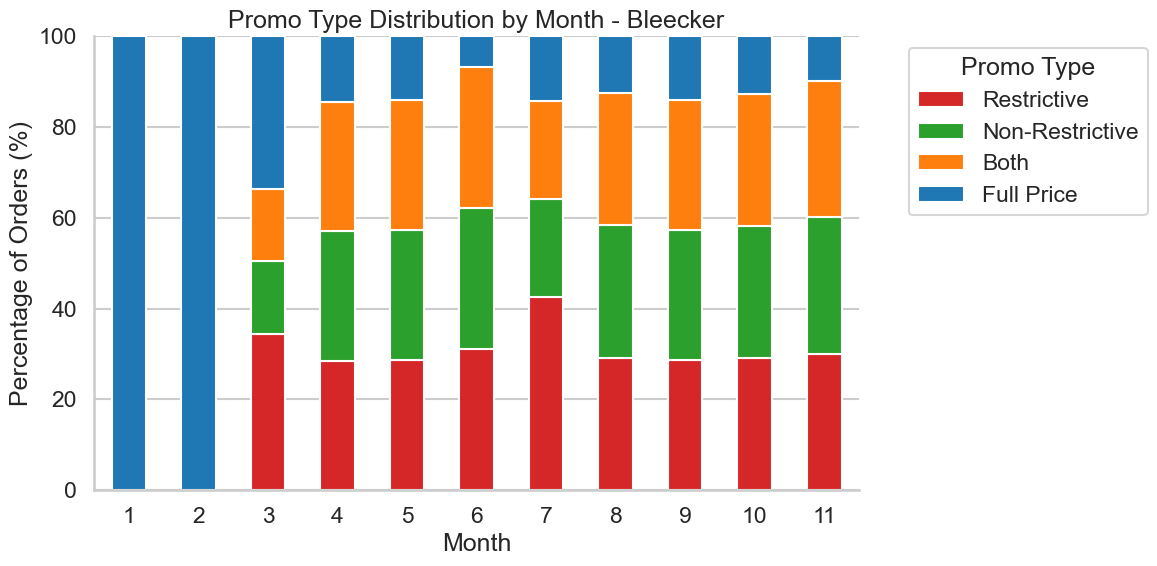

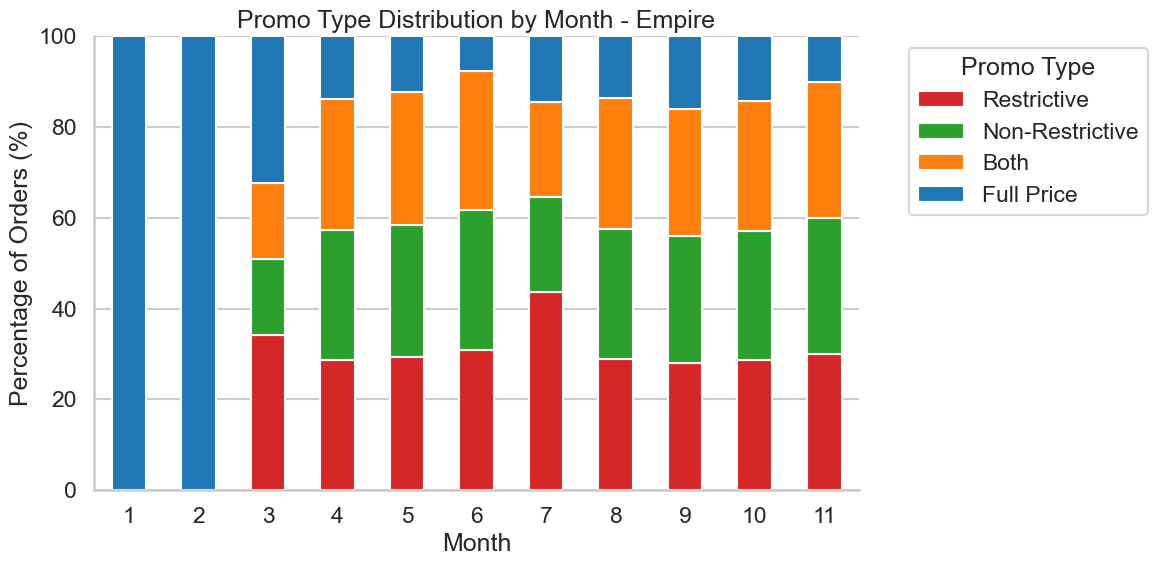

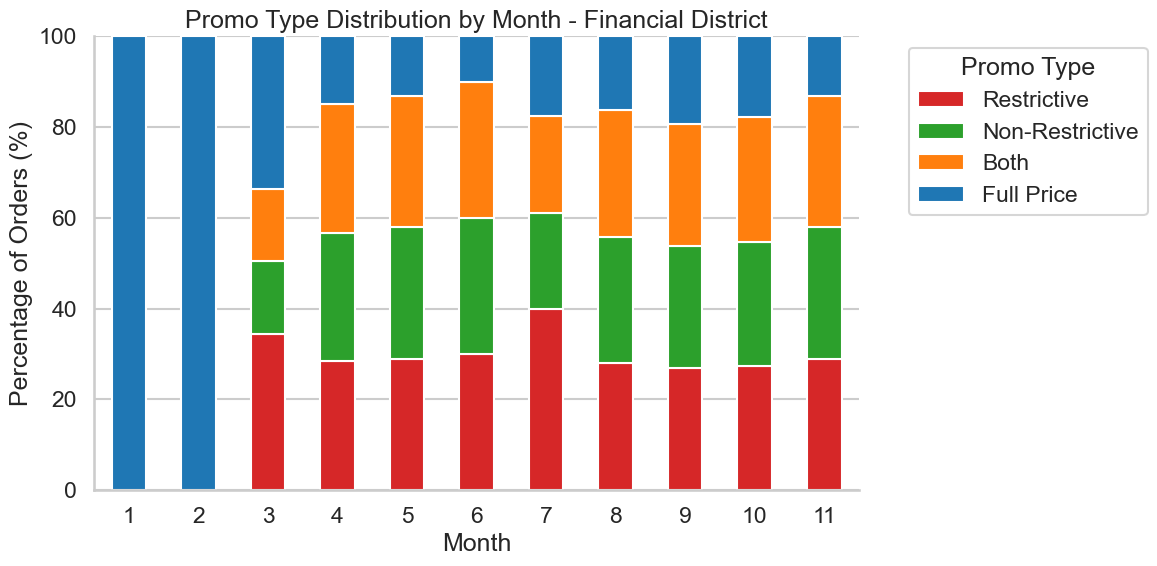

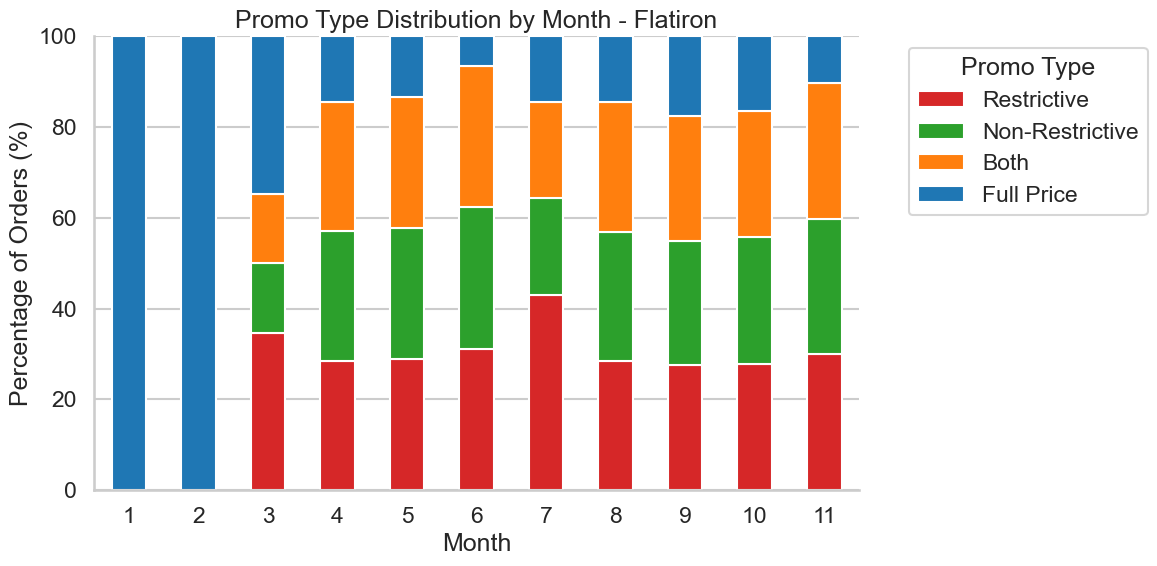

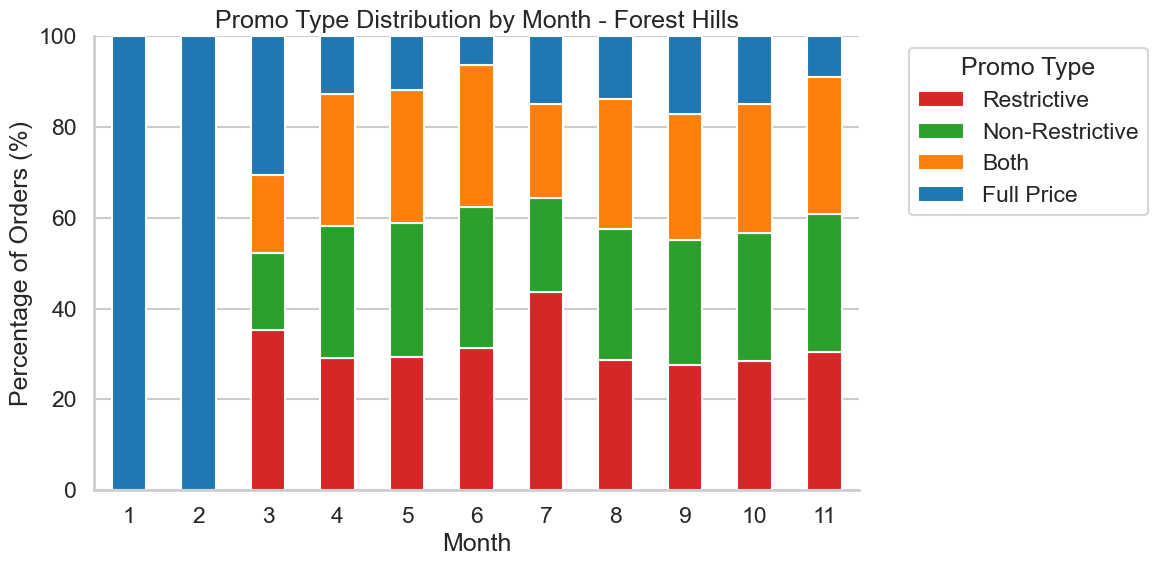

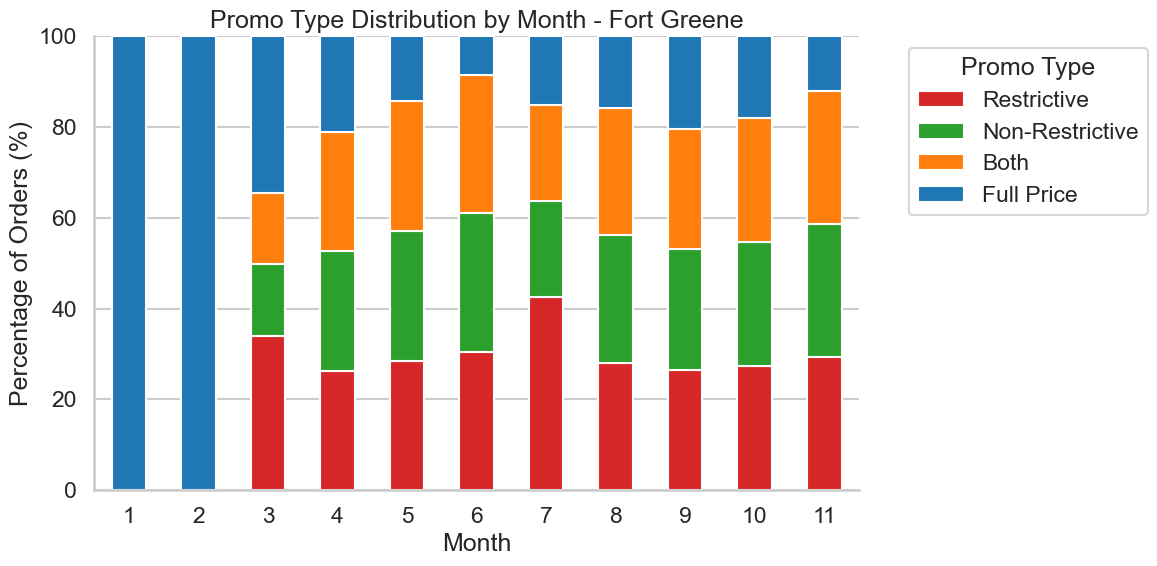

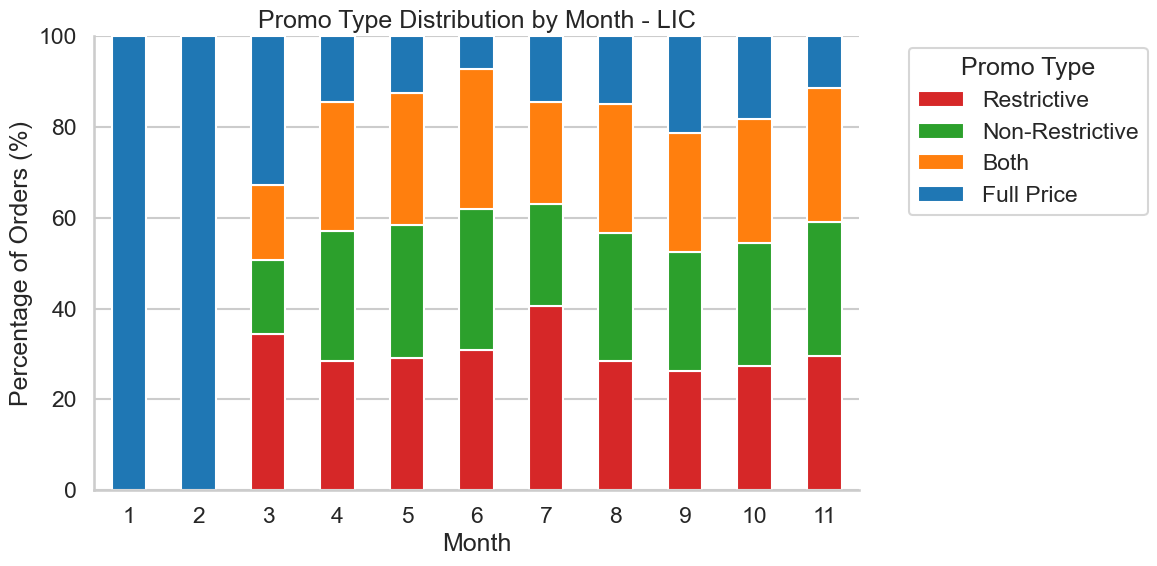

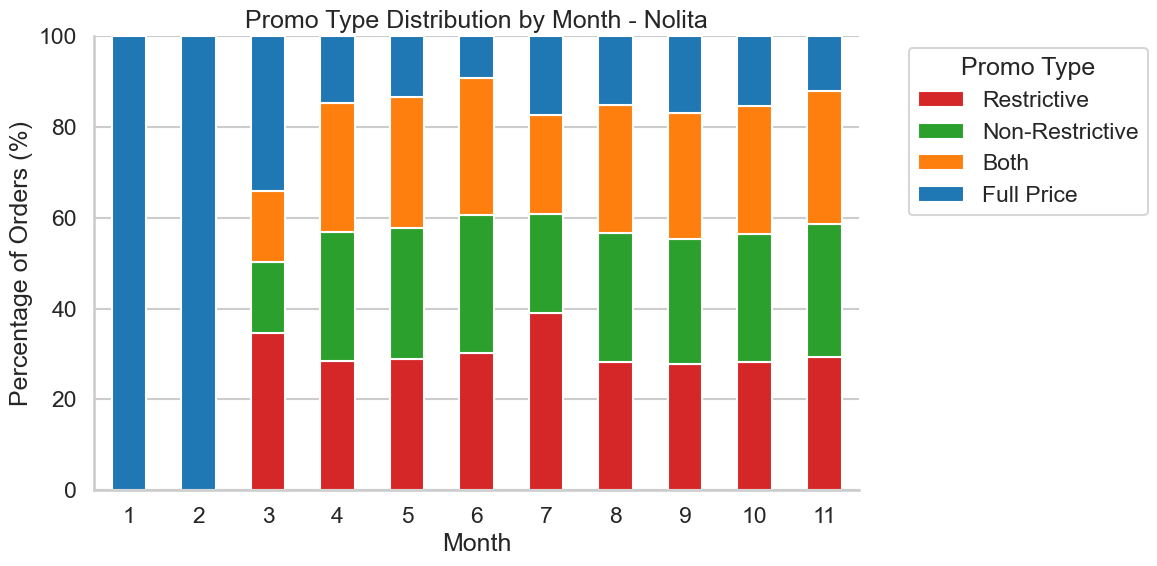

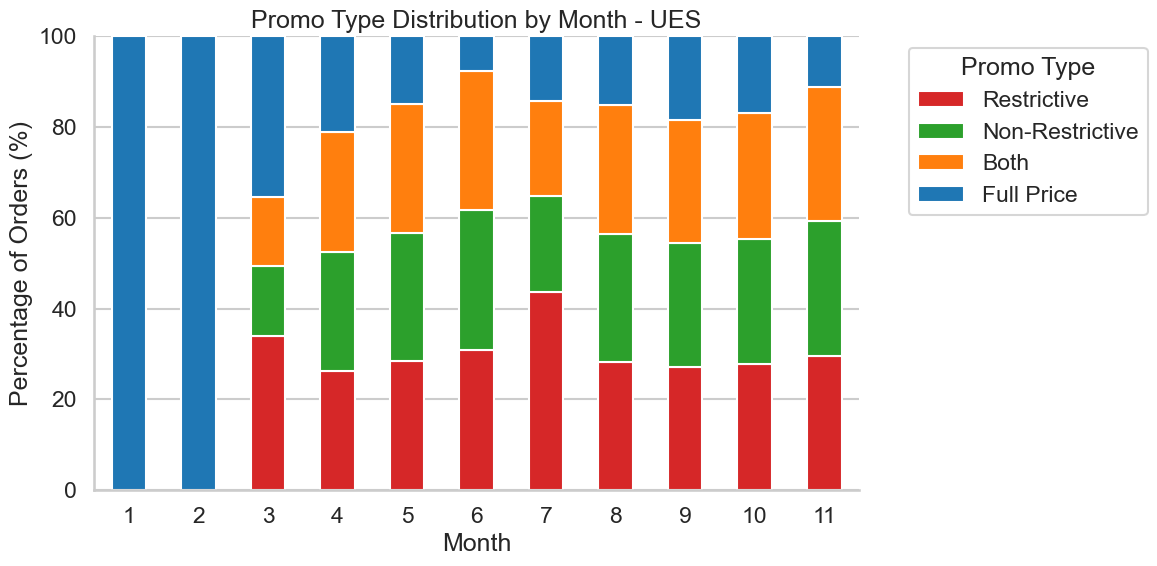

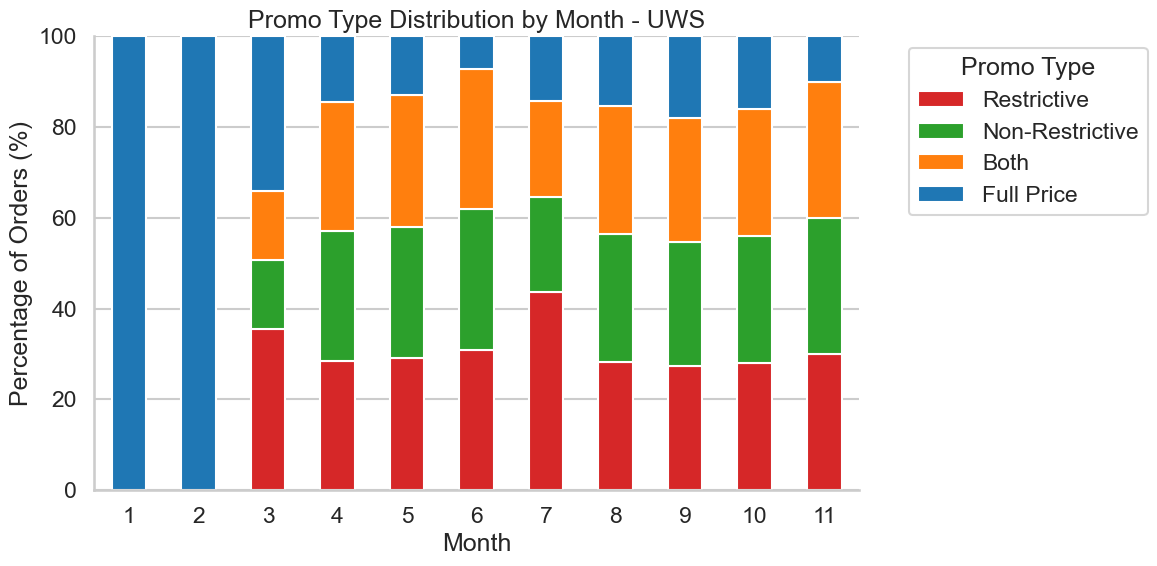

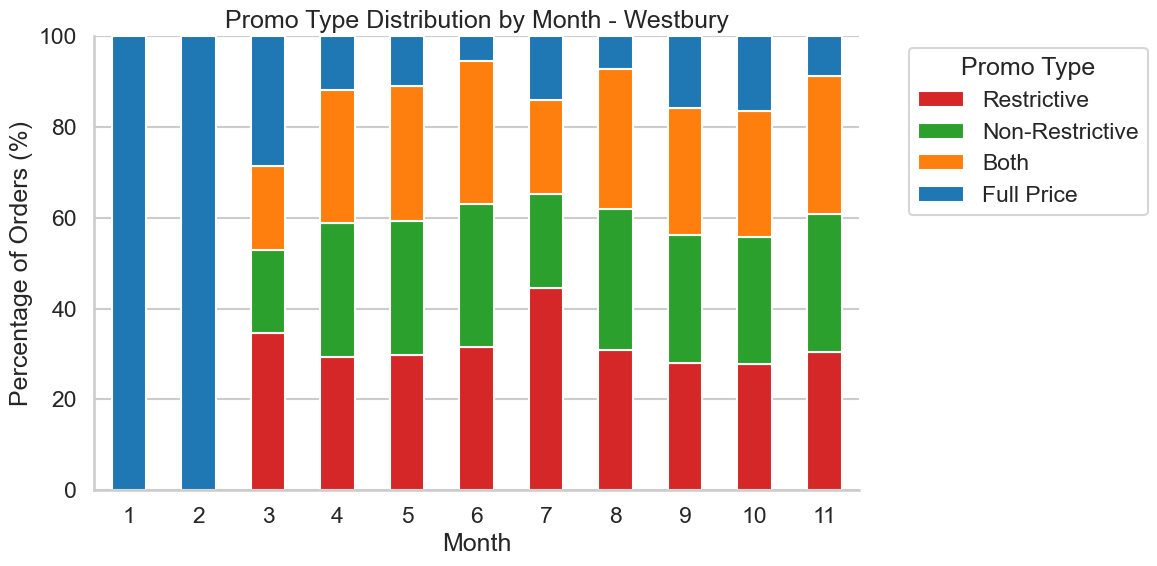

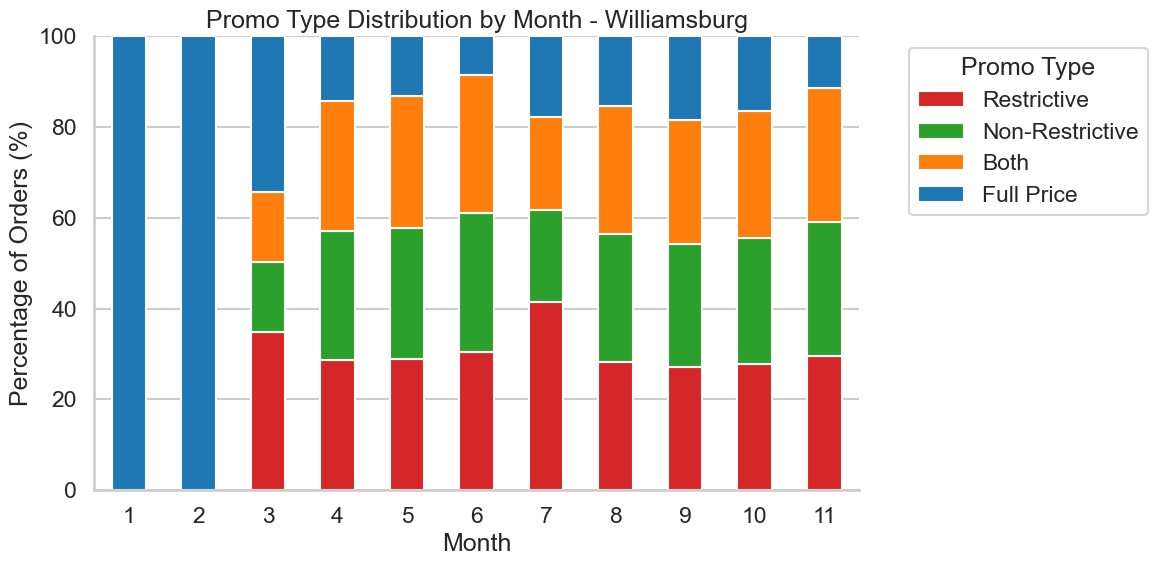

In [17]:
store_month_counts = ny_data.groupby(["Store Name", "Month"])[promo_types].sum()
store_month_pct = store_month_counts.div(store_month_counts.sum(axis=1), axis=0) * 100
store_month_pct = store_month_pct.reset_index()
stores = store_month_pct["Store Name"].unique()

for store in stores:
    df = store_month_pct[store_month_pct["Store Name"] == store]
    df = df.set_index("Month")[promo_types]  
    
    df.plot(
        kind="bar",
        stacked=True,
        figsize=(12, 6),
        color=[palette[col] for col in promo_types]
    )
    
    plt.title(f"Promo Type Distribution by Month - {store}")
    plt.xlabel("Month")
    plt.ylabel("Percentage of Orders (%)")
    plt.ylim(0, 100)
    plt.xticks(rotation=0)
    plt.legend(title="Promo Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

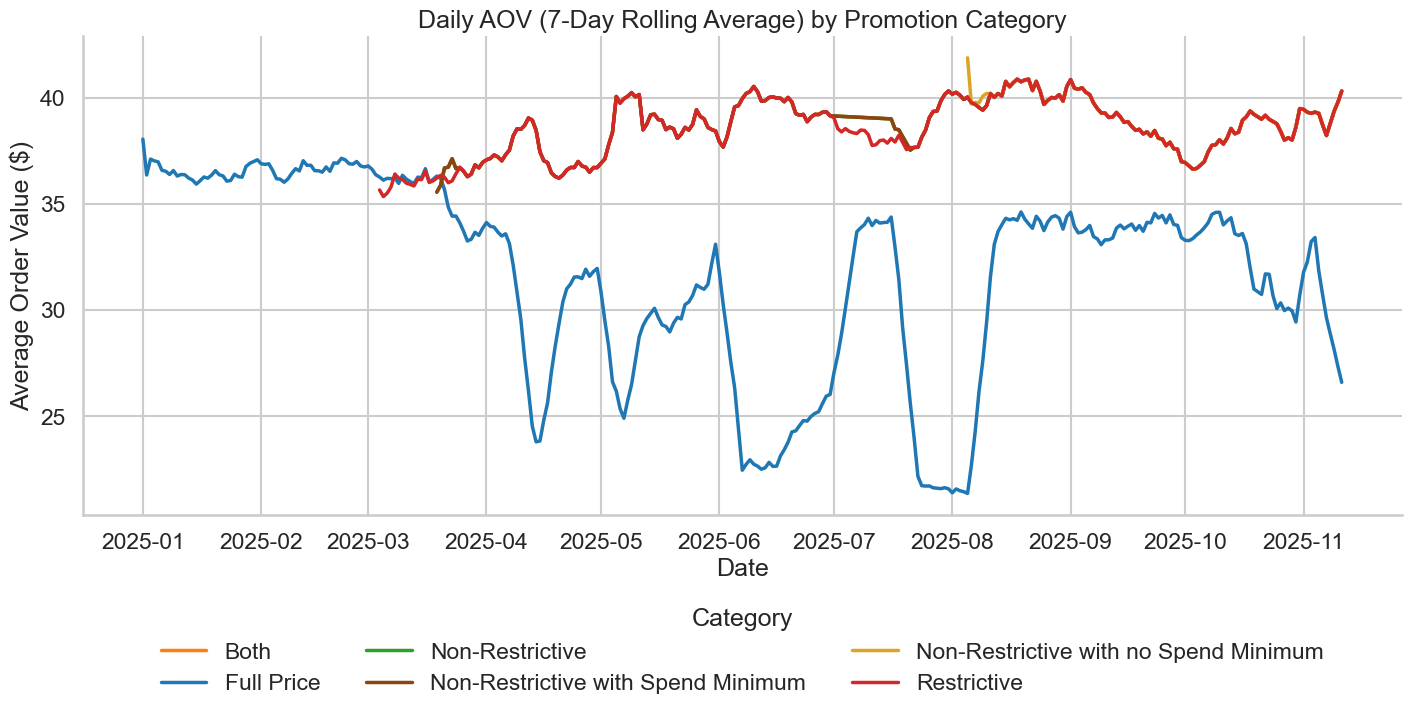

In [18]:
categories = [
    "Restrictive",
    "Non-Restrictive",
    "Non-Restrictive with Spend Minimum",
    "Non-Restrictive with no Spend Minimum",
    "Both",
    "Full Price"
]







long = sales_data.melt(
    id_vars=["Order Date", "Sales (excl. tax)"],
    value_vars=categories,
    var_name="Category",
    value_name="Flag"
)


long = long[long["Flag"] == 1]

#Daily AOV 
daily_aov = (
    long
    .groupby([long["Order Date"].dt.date, "Category"])
    ["Sales (excl. tax)"]
    .mean()
    .reset_index()
    .rename(columns={"Sales (excl. tax)": "AOV"})
)

daily_aov["Order Date"] = pd.to_datetime(daily_aov["Order Date"])

daily_aov = daily_aov.sort_values(["Category", "Order Date"])

# 7-day rolling average
daily_aov["AOV_7d"] = (
    daily_aov
    .groupby("Category")["AOV"]
    .rolling(window=7, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

palette = {
    "Restrictive": "#D62728",                   # red
    "Non-Restrictive": "#2CA02C",               # green
    "Non-Restrictive with Spend Minimum": "#8B4513",  # brown
    "Non-Restrictive with no Spend Minimum": "#DAA520", # darker yellow
    "Both": "#FF7F0E",                          # orange
    "Full Price": "#1F77B4"                     # blue
}

plt.figure(figsize=(14, 7), constrained_layout=True)

sns.lineplot(
    data=daily_aov,
    x="Order Date",
    y="AOV_7d",
    palette=palette,
    hue="Category",
    linewidth=2.5
)

plt.title("Daily AOV (7-Day Rolling Average) by Promotion Category")
plt.xlabel("Date")
plt.ylabel("Average Order Value ($)")

plt.legend(
    title="Category",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False
)

plt.show()

In [19]:
sales_data.columns

Index(['Sales (excl. tax)', 'Order Date', 'Order Day', 'Promo', 'Full Price',
       'Day Part', 'Store Name', 'Dining Mode', 'Order Status',
       'Customer Uber-Membership Status', 'Offers on items (incl. tax)',
       'Tax On Offers on items', 'Year', 'Month', 'DayOfWeek',
       'Buy 1, Get 1 Free', 'Spend 30, Save 8', 'Spend 45, Save 15',
       'Spend 40, Save 11', 'Save on Menu Items', '25% off', '30% off',
       'Spend 35, Save 8', 'Spend 30, Save 12', 'Spend 35, Save 7',
       'Buy 1, get a free item', 'Spend 35, Save 10', '40% off, up to $30 ',
       '25% off, up to $35 ', '30% off, up to $35 ', 'Spend 40, Save 10',
       'Spend 45, Save 12', 'Restrictive', 'Non-Restrictive',
       'Non-Restrictive with Spend Minimum',
       'Non-Restrictive with no Spend Minimum', 'Both', 'Campaign Type',
       'State', 'Net Promo', 'Promo %', 'Payout', 'Margin %', 'Quarter'],
      dtype='object')

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


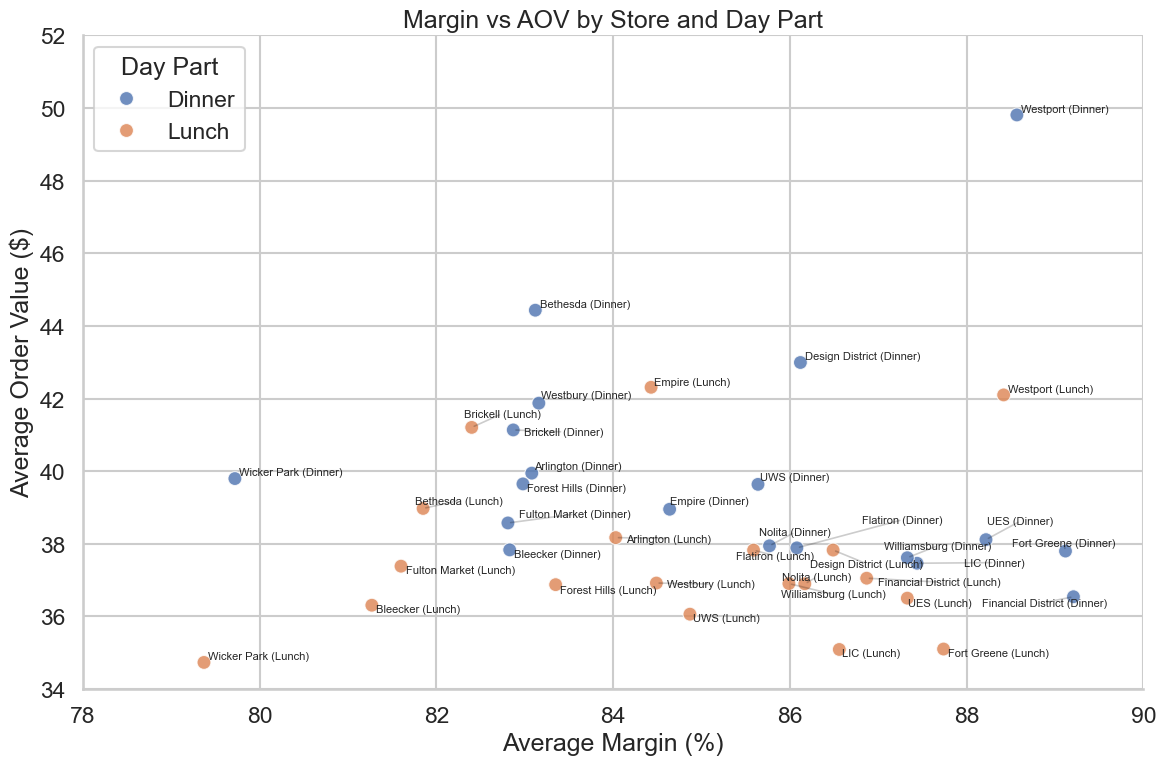

In [20]:
from adjustText import adjust_text
store_metrics = (
    sales_data
    .groupby(["Store Name", "Day Part"], as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean"),
    )
)

store_metrics[["aov", "avg_margin"]] = store_metrics[["aov", "avg_margin"]].round(4)
store_metrics["avg_margin_pct"] = store_metrics["avg_margin"] * 100

plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=store_metrics,
    x="avg_margin_pct",
    y="aov",
    hue="Day Part",        
    alpha=0.8,
    s=100
)
texts = []

for _, row in store_metrics.iterrows():
    texts.append(
        ax.text(
            row["avg_margin_pct"],
            row["aov"],
            f"{row['Store Name']} ({row['Day Part']})",
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    expand_points=(1.4, 1.4),
    expand_text=(1.4, 1.4),
    force_text=0.8,
    force_points=0.6,
    min_arrow_len=5,
    arrowprops=dict(
        arrowstyle="-",
        color="black",
        lw=1.2,
        alpha=0.2,
    )
)


plt.title("Margin vs AOV by Store and Day Part")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")

plt.xlim(78, 90)
plt.ylim(34, 52)

plt.legend(title="Day Part")
plt.tight_layout()
plt.show()

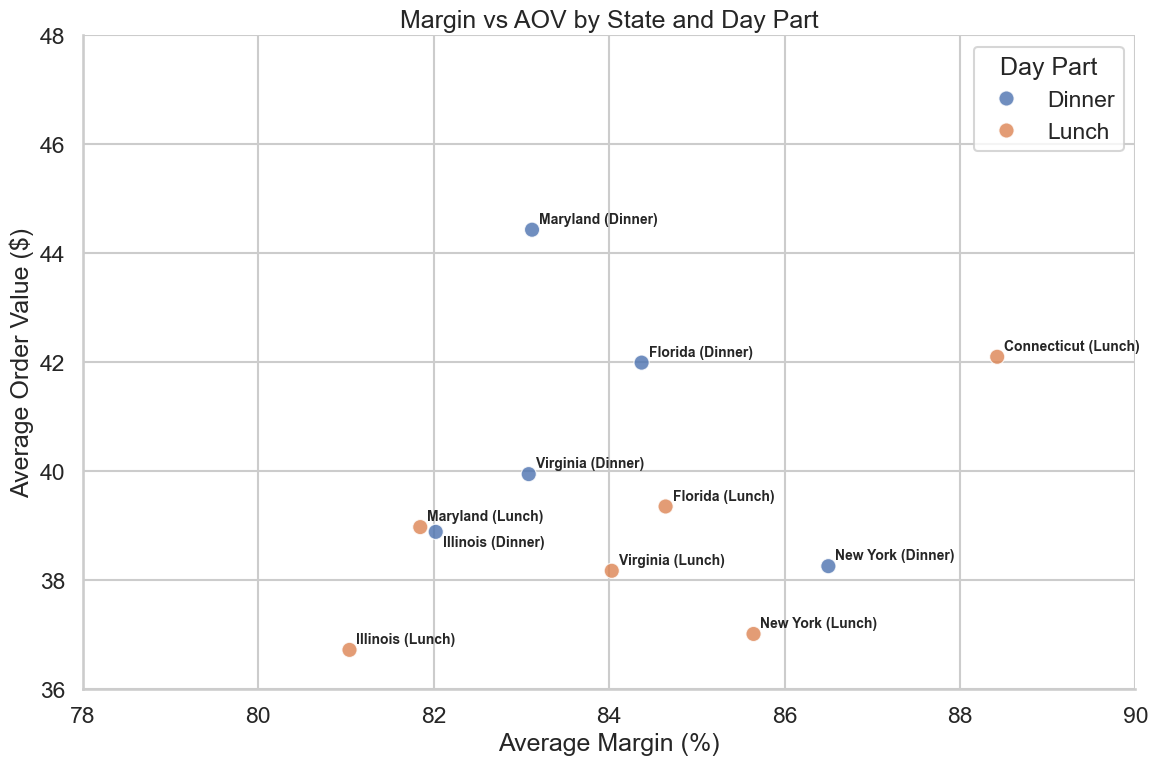

In [21]:
state_metrics = (
    sales_data
    .groupby(["State", "Day Part"], as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean"),
        orders=("Sales (excl. tax)", "count")
    )
)

state_metrics["avg_margin_pct"] = state_metrics["avg_margin"] * 100
state_metrics["aov"] = state_metrics["aov"].round(4)

plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=state_metrics,
    x="avg_margin_pct",
    y="aov",
    hue="Day Part",
    alpha=0.8,
    s=120
)

for _, row in state_metrics.iterrows():
    ax.annotate(
        f"{row['State']} ({row['Day Part']})",
        (row["avg_margin_pct"], row["aov"]),
        xytext=(5, -10) if (row["State"] == "Illinois" and row["Day Part"] == "Dinner") else (5, 5),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Margin vs AOV by State and Day Part")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")

plt.xlim(78, 90)
plt.ylim(36, 48)

plt.legend(title="Day Part")
plt.tight_layout()
plt.show()

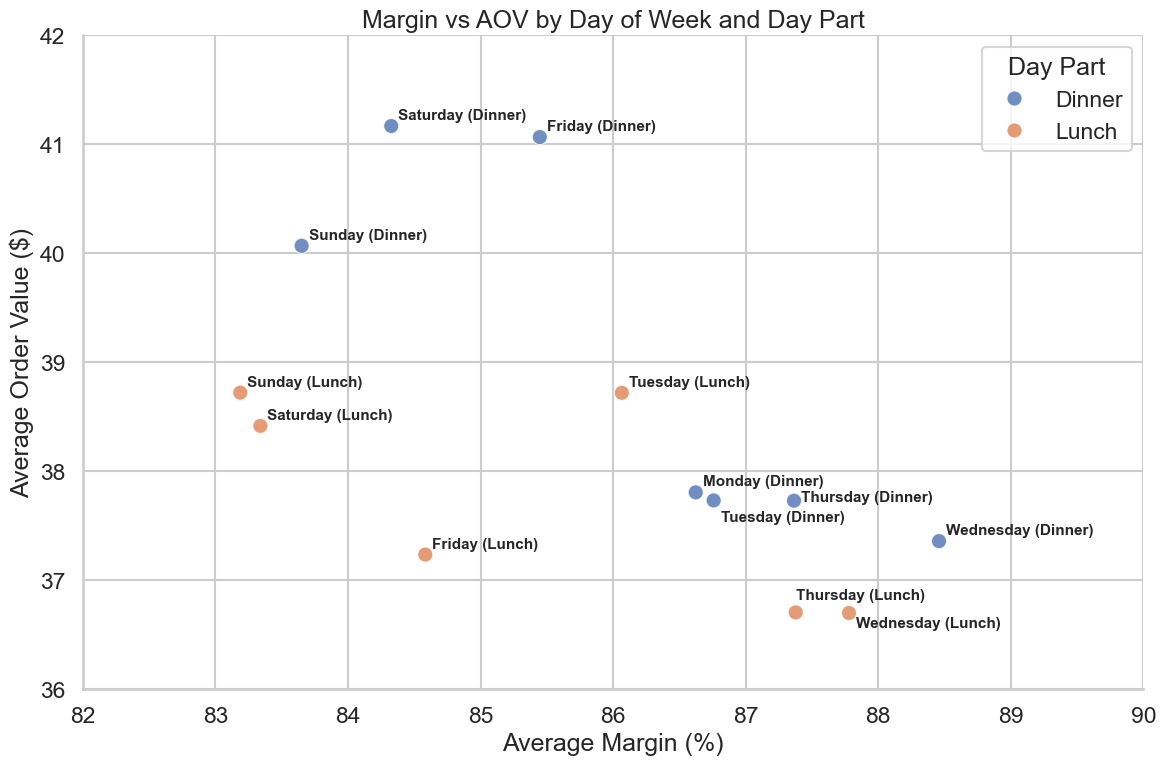

In [22]:
day_metrics = (
    sales_data
    .groupby(["DayOfWeek", "Day Part"], as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean"),
        orders=("Sales (excl. tax)", "count")
    )
)

day_metrics["avg_margin_pct"] = day_metrics["avg_margin"] * 100
day_metrics["aov"] = day_metrics["aov"].round(4)

plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=day_metrics,
    x="avg_margin_pct",
    y="aov",
    hue="Day Part",     

    s=120,
    alpha=0.8
)

offsets = {
    ("Monday", "Lunch"): (5, 5),
    ("Tuesday", "Lunch"): (5, 5),
    ("Wednesday", "Lunch"): (5, -10),
    ("Thursday", "Lunch"): (0, 10),
    ("Friday", "Lunch"): (5, 5),
    ("Saturday", "Lunch"): (5, 5),
    ("Sunday", "Lunch"): (5, 5),
    ("Monday", "Dinner"): (5, 5),
    ("Tuesday", "Dinner"): (5, -15),
    ("Wednesday", "Dinner"): (5, 5),
    ("Thursday", "Dinner"): (5, 0),
    ("Friday", "Dinner"): (5, 5),
    ("Saturday", "Dinner"): (5, 5),
    ("Sunday", "Dinner"): (5, 5),
}

for _, row in day_metrics.iterrows():
    xy_offset = offsets.get((row["DayOfWeek"], row["Day Part"]), (5, 5))
    
    ax.annotate(
        f"{row['DayOfWeek']} ({row['Day Part']})",
        (row["avg_margin_pct"], row["aov"]),
        xytext=xy_offset,
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Margin vs AOV by Day of Week and Day Part")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")

plt.xlim(82, 90)
plt.ylim(36, 42)

plt.legend(title="Day Part")
plt.tight_layout()
plt.show()

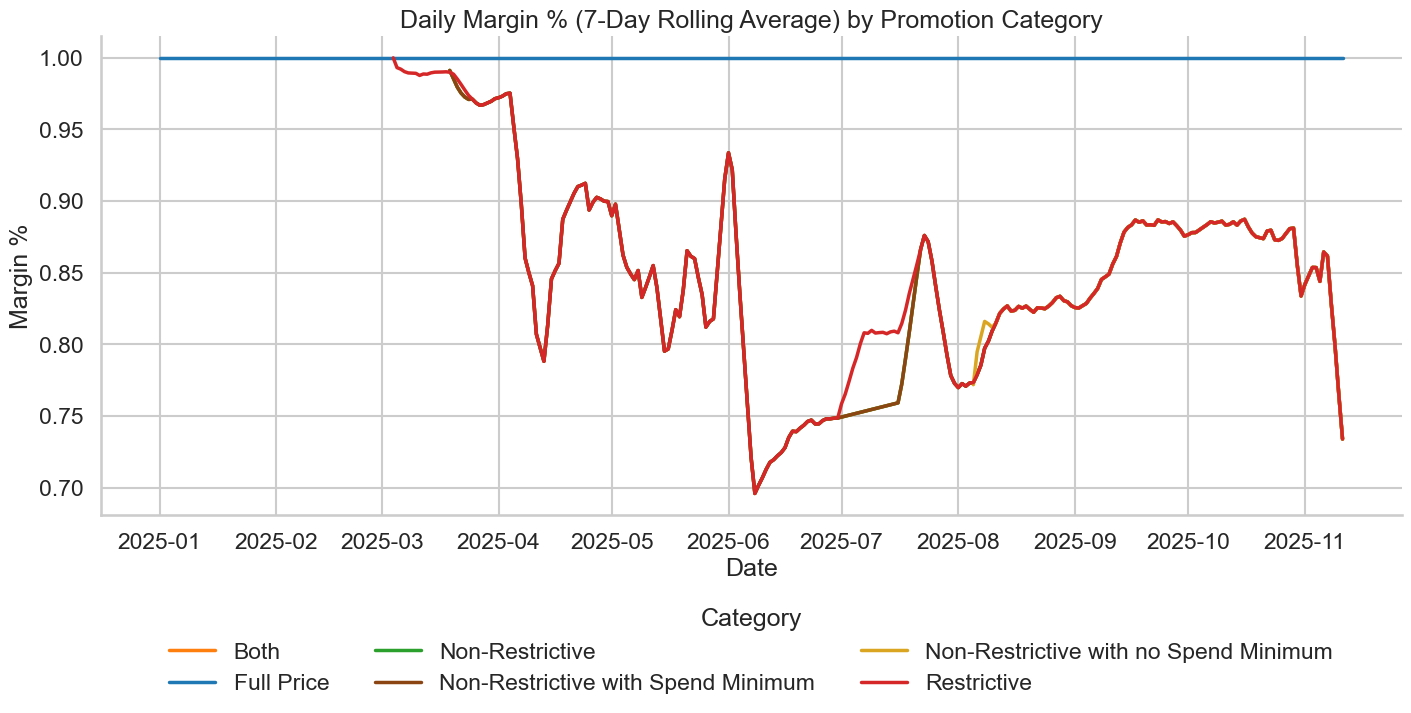

In [23]:
categories = [
    "Restrictive",
    "Non-Restrictive",
    "Non-Restrictive with Spend Minimum",
    "Non-Restrictive with no Spend Minimum",
    "Both",
    "Full Price"
]


long = sales_data.melt(
    id_vars=["Order Date", "Margin %"],
    value_vars=categories,
    var_name="Category",
    value_name="Flag"
)


long = long[long["Flag"] == 1]


daily_margin = (
    long
    .groupby([long["Order Date"].dt.date, "Category"])["Margin %"]
    .mean()
    .reset_index()
    .rename(columns={"Margin %": "Margin"})
)

daily_margin["Order Date"] = pd.to_datetime(daily_margin["Order Date"])


daily_margin = daily_margin.sort_values(["Category", "Order Date"])


daily_margin["Margin_7d"] = (
    daily_margin
    .groupby("Category")["Margin"]
    .rolling(window=7, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)


palette = {
    "Restrictive": "#D62728",                   # red
    "Non-Restrictive": "#2CA02C",               # green
    "Non-Restrictive with Spend Minimum": "#8B4513",  # brown
    "Non-Restrictive with no Spend Minimum": "#DAA520", # yellow
    "Both": "#FF7F0E",                          # orange
    "Full Price": "#1F77B4"                     # blue
}


plt.figure(figsize=(14, 7), constrained_layout=True)

sns.lineplot(
    data=daily_margin,
    x="Order Date",
    y="Margin_7d",
    hue="Category",
    palette=palette,
    linewidth=2.5
)

plt.title("Daily Margin % (7-Day Rolling Average) by Promotion Category")
plt.xlabel("Date")
plt.ylabel("Margin %")

plt.legend(
    title="Category",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False
)

plt.show()

210 [0.91163181 0.48670764]
212 [-0.47529411  0.57949717]
213 [ 0.54077414 -0.80501067]
204 [-0.87112053  0.82801962]
206 [-0.48795546  0.38362761]
207 [ 0.77984477 -0.02007298]
30 [0.71841328 0.19573719]
32 [-0.50499185 -0.65903091]
33 [-0.58012319  0.12830244]
18 [0.43671494 0.41038309]
20 [-0.7689988  -0.46524966]
21 [-0.29861277 -0.97814907]
6 [-0.08667054 -0.31756373]
8 [0.40067718 0.95731791]
9 [-0.17069882 -0.89945644]
126 [-0.25438263 -0.21832119]
128 [0.08623318 0.92874406]
129 [0.08826667 0.94174044]
0 [-0.66473181  0.24099867]
2 [-0.76671016  0.4443792 ]
3 [-0.76130997 -0.31123968]
42 [0.39067188 0.91743674]
44 [-0.05688776  0.79108849]
45 [0.42263444 0.65818683]
36 [-0.48188568 -0.12509015]
38 [ 0.85810933 -0.67159288]
39 [-0.89065907 -0.16157825]
102 [0.72671805 0.13433883]
104 [ 0.20304792 -0.5603649 ]
105 [-0.6651847   0.18798069]
12 [-0.65150177 -0.54970441]
14 [ 0.30293877 -0.10250033]
15 [-0.91109546  0.41717475]
24 [0.812512   0.07694989]
26 [-0.44673678 -0.39934537]

C:\Users\willi\AppData\Local\Temp\ipykernel_5992\1186460182.py:98: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


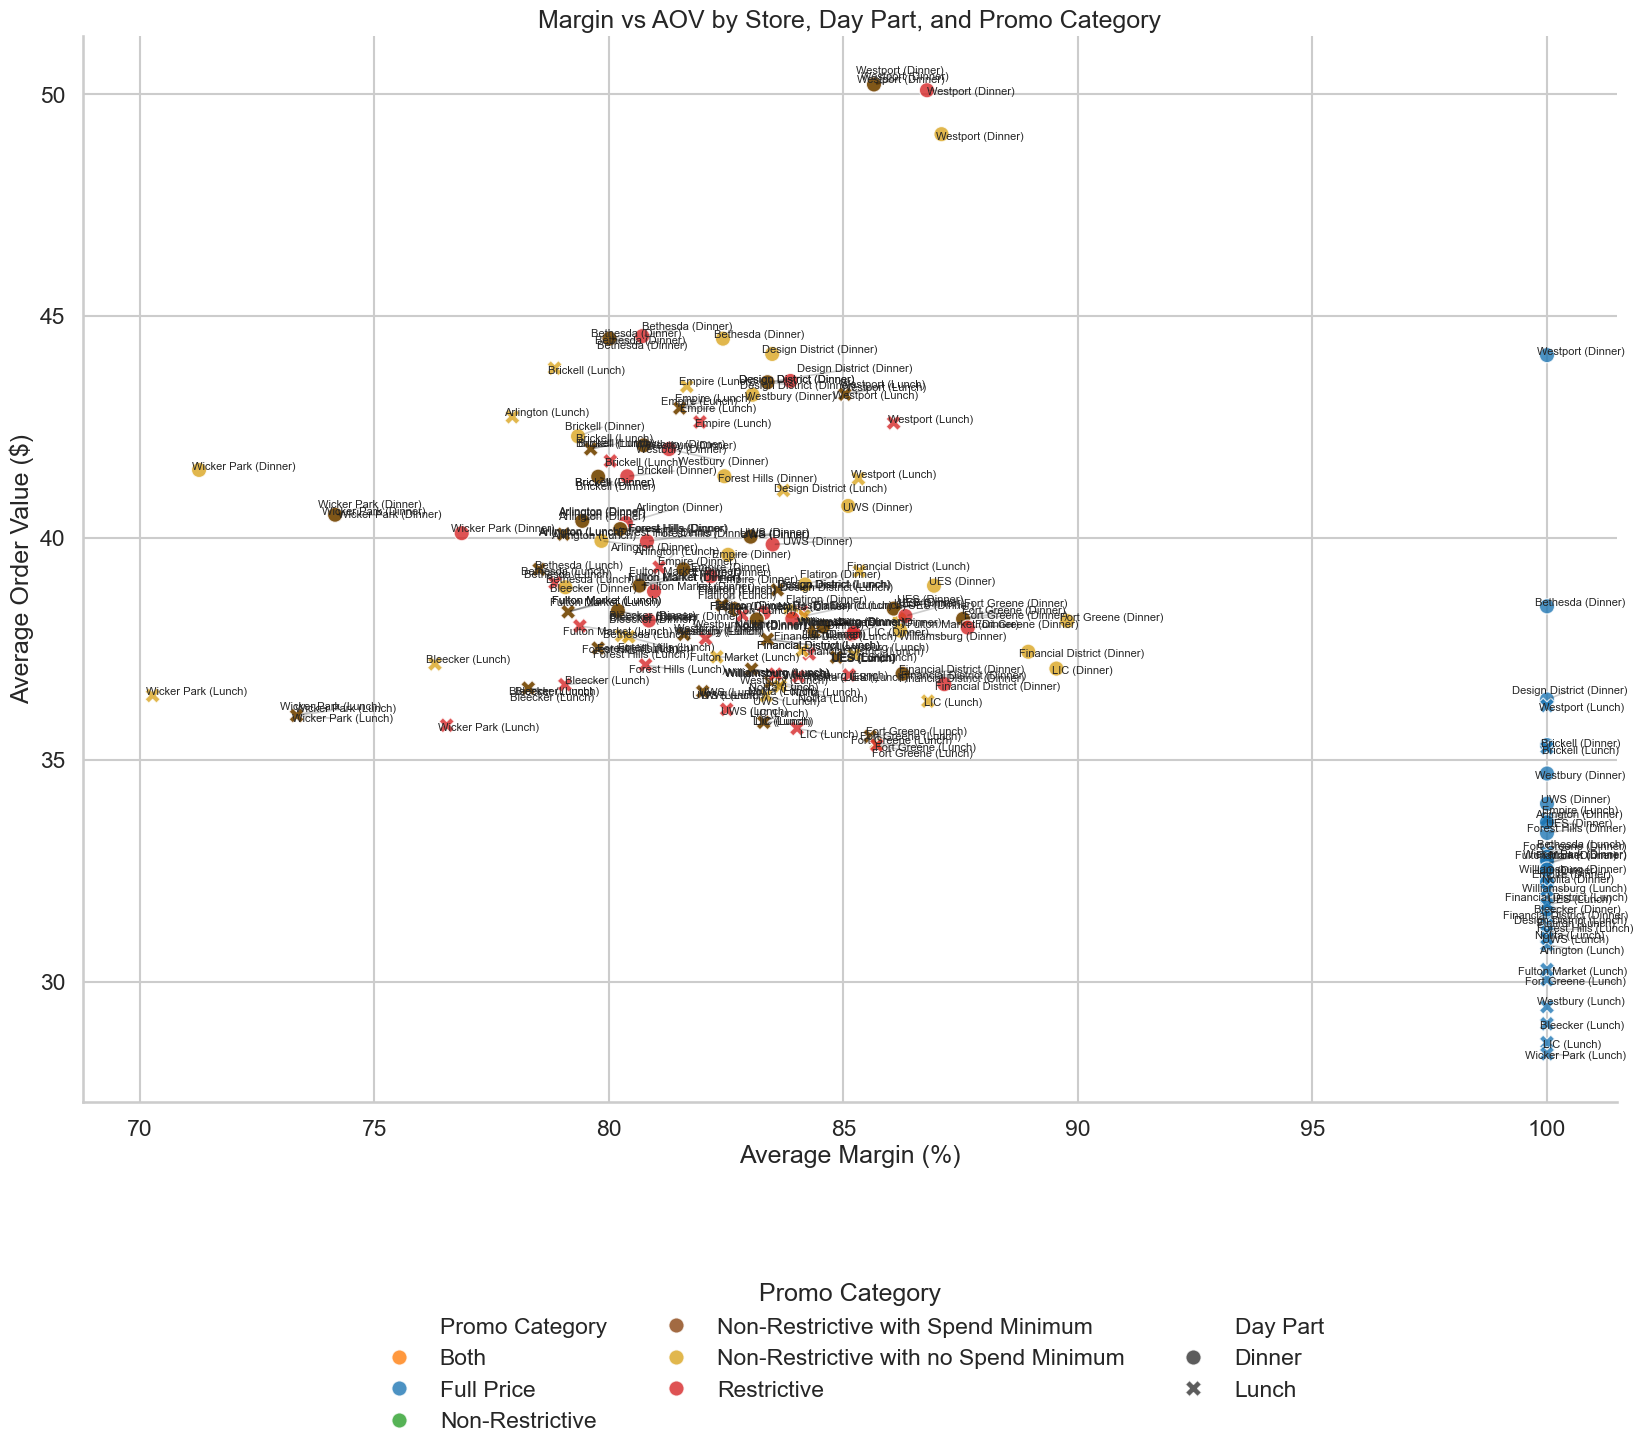

In [24]:
categories = [
    "Restrictive",
    "Non-Restrictive",
    "Non-Restrictive with Spend Minimum",
    "Non-Restrictive with no Spend Minimum",
    "Both",
    "Full Price"
]

# Melt the data to long format so each order has one row per active category
long = sales_data.melt(
    id_vars=["Store Name", "Day Part", "Sales (excl. tax)", "Margin %"],
    value_vars=categories,
    var_name="Promo Category",
    value_name="Flag"
)

# Keep only active categories
long = long[long["Flag"] == 1]

# Aggregate by Store + Day Part + Promo Category
store_metrics = (
    long
    .groupby(["Store Name", "Day Part", "Promo Category"], as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
)

# Round and compute margin %
store_metrics[["aov", "avg_margin"]] = store_metrics[["aov", "avg_margin"]].round(4)
store_metrics["avg_margin_pct"] = store_metrics["avg_margin"] * 100

# Define a color palette for Promo Category
palette = {
    "Restrictive": "#D62728",                   
    "Non-Restrictive": "#2CA02C",               
    "Non-Restrictive with Spend Minimum": "#8B4513",  
    "Non-Restrictive with no Spend Minimum": "#DAA520", 
    "Both": "#FF7F0E",                          
    "Full Price": "#1F77B4"                     
}

# Scatterplot
plt.figure(figsize=(20, 20), constrained_layout=True)
ax = sns.scatterplot(
    data=store_metrics,
    x="avg_margin_pct",
    y="aov",
    hue="Promo Category",      # color by promo
    style="Day Part",          # shape by day part
    s=120,
    alpha=0.8,
    palette=palette
)

# Annotate only with store name + day part
texts = []
for _, row in store_metrics.iterrows():
    texts.append(
        ax.text(
            row["avg_margin_pct"],
            row["aov"],
            f"{row['Store Name']} ({row['Day Part']})",
            fontsize=8
        )
    )

# Adjust text to avoid overlaps
adjust_text(
    texts,
    ax=ax,
    expand_points=(1.4, 1.4),
    expand_text=(1.4, 1.4),
    force_text=0.8,
    force_points=0.6,
    min_arrow_len=5,
    arrowprops=dict(
        arrowstyle="-",
        color="black",
        lw=1.2,
        alpha=0.2,
    )
)

plt.title("Margin vs AOV by Store, Day Part, and Promo Category")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")

plt.legend(
    title="Promo Category",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15), 
    ncol=3,                        
    frameon=False
)
plt.tight_layout()
plt.show()

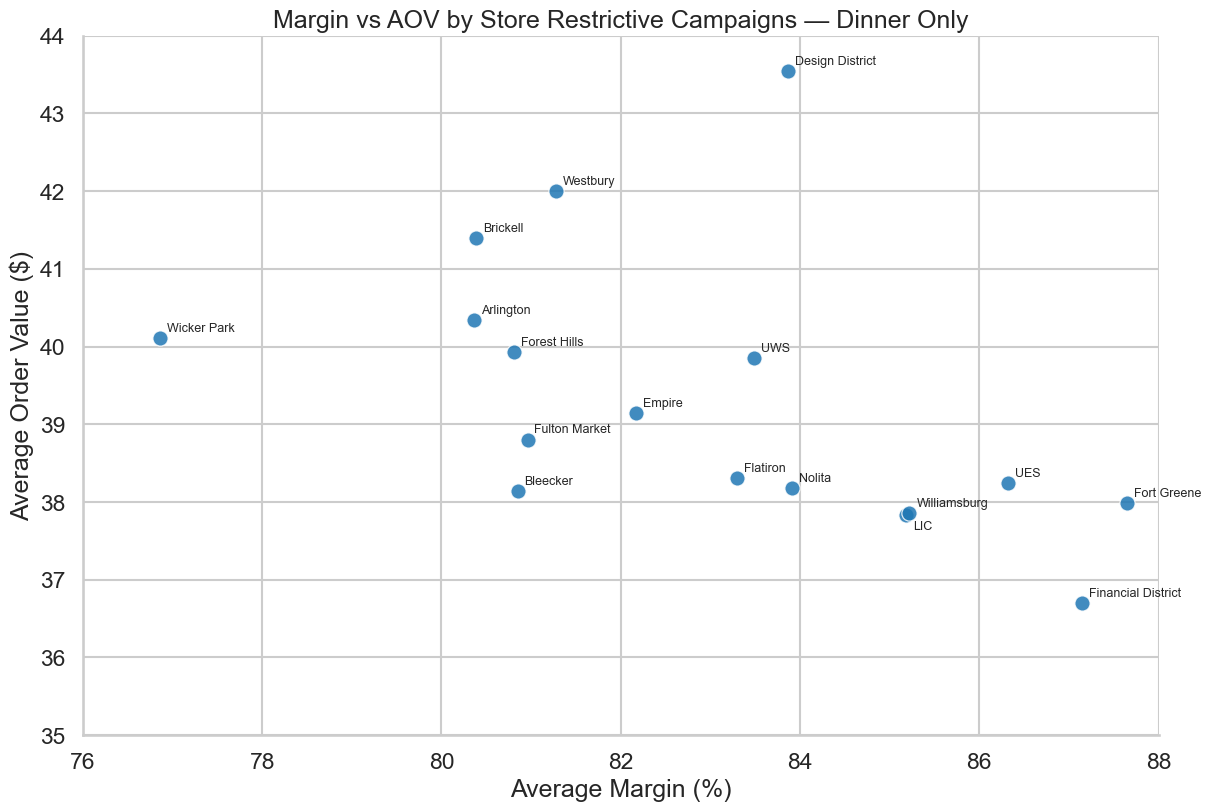

In [25]:
filtered = sales_data[
    (sales_data["Restrictive"] == 1) &
    (sales_data["Day Part"] == "Dinner")
]


store_metrics = (
    filtered
    .groupby("Store Name", as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
)

store_metrics["avg_margin_pct"] = store_metrics["avg_margin"] * 100
store_metrics[["aov", "avg_margin_pct"]] = store_metrics[
    ["aov", "avg_margin_pct"]
].round(2)


plt.figure(figsize=(12, 8), constrained_layout=True)

ax = sns.scatterplot(
    data=store_metrics,
    x="avg_margin_pct",
    y="aov",
    color="#1F77B4",  
    s=120,
    alpha=0.85
)


for _, row in store_metrics.iterrows():
    ax.annotate(
        row["Store Name"],
        (row["avg_margin_pct"], row["aov"]),
        xytext=(5, -10) if (row["Store Name"] == "LIC") else (5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Margin vs AOV by Store Restrictive Campaigns — Dinner Only")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")
plt.xlim(76, 88)
plt.ylim(35, 44)
plt.show()

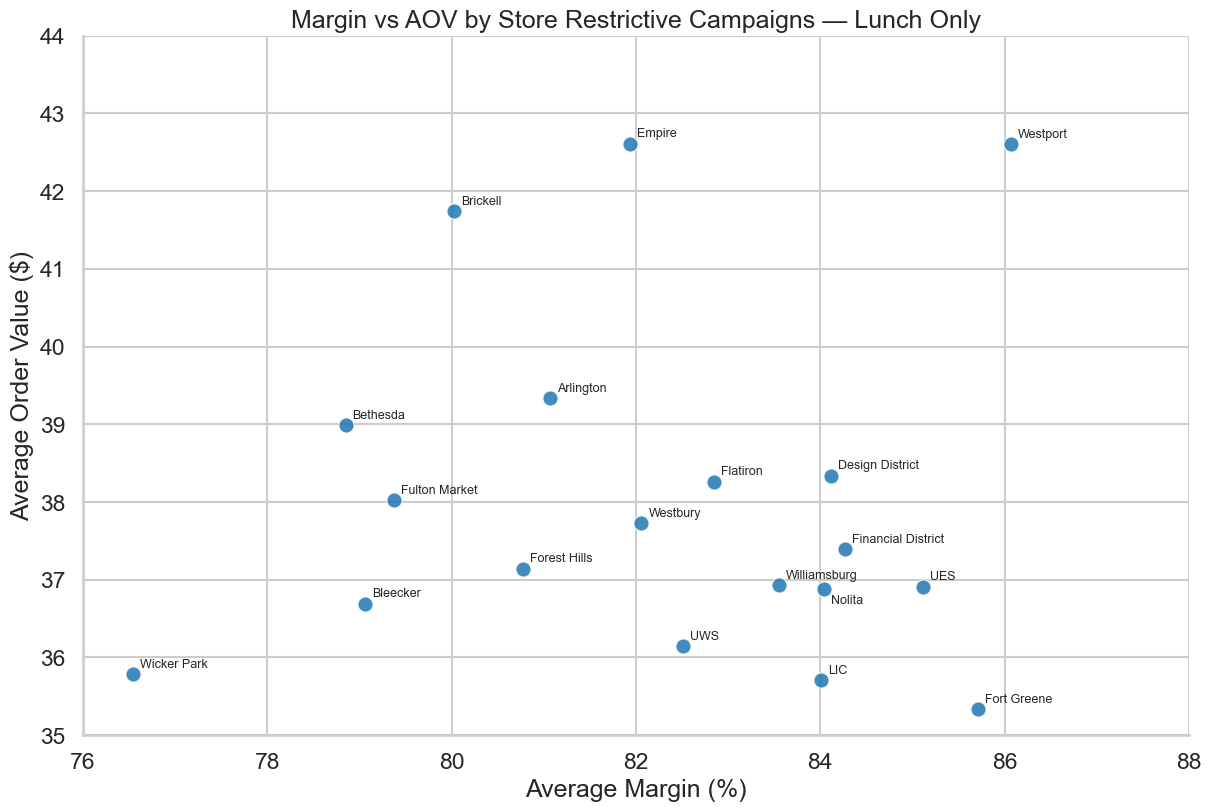

In [26]:
filtered = sales_data[
    (sales_data["Restrictive"] == 1) &
    (sales_data["Day Part"] == "Lunch")
]

store_metrics = (
    filtered
    .groupby("Store Name", as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
)

store_metrics["avg_margin_pct"] = store_metrics["avg_margin"] * 100
store_metrics[["aov", "avg_margin_pct"]] = store_metrics[
    ["aov", "avg_margin_pct"]
].round(2)

# Plot
plt.figure(figsize=(12, 8), constrained_layout=True)

ax = sns.scatterplot(
    data=store_metrics,
    x="avg_margin_pct",
    y="aov",
    color="#1F77B4" ,   
    s=120,
    alpha=0.85
)


for _, row in store_metrics.iterrows():
    ax.annotate(
        row["Store Name"],
        (row["avg_margin_pct"], row["aov"]),
        xytext=(5, -10) if (row["Store Name"] == "Nolita") else (5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Margin vs AOV by Store Restrictive Campaigns — Lunch Only")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")
plt.xlim(76, 88)
plt.ylim(35, 44)
plt.show()

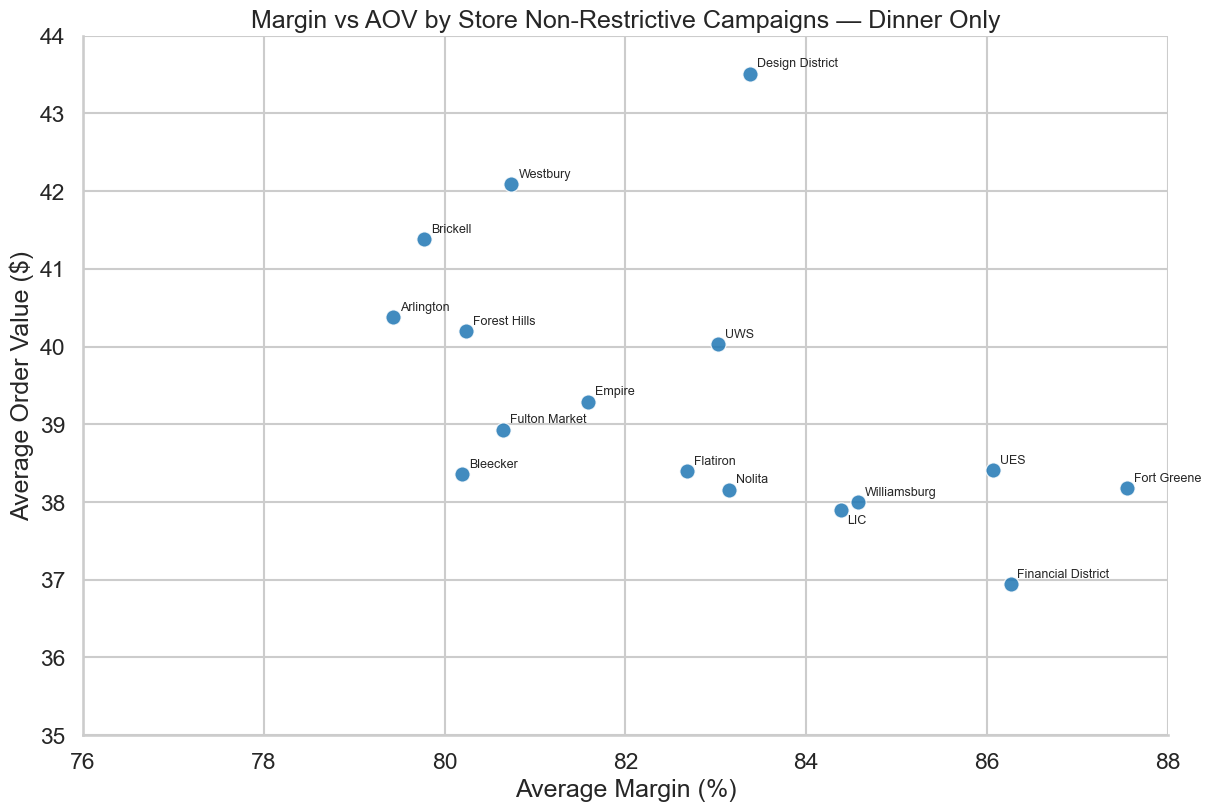

In [27]:
filtered = sales_data[
    (sales_data["Non-Restrictive"] == 1) &
    (sales_data["Day Part"] == "Dinner")
]


store_metrics = (
    filtered
    .groupby("Store Name", as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
)

store_metrics["avg_margin_pct"] = store_metrics["avg_margin"] * 100
store_metrics[["aov", "avg_margin_pct"]] = store_metrics[
    ["aov", "avg_margin_pct"]
].round(2)


plt.figure(figsize=(12, 8), constrained_layout=True)

ax = sns.scatterplot(
    data=store_metrics,
    x="avg_margin_pct",
    y="aov",
    color="#1F77B4",  
    s=120,
    alpha=0.85
)


for _, row in store_metrics.iterrows():
    ax.annotate(
        row["Store Name"],
        (row["avg_margin_pct"], row["aov"]),
        xytext=(5, -10) if (row["Store Name"] == "LIC") else (5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Margin vs AOV by Store Non-Restrictive Campaigns — Dinner Only")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")
plt.xlim(76, 88)
plt.ylim(35, 44)
plt.show()

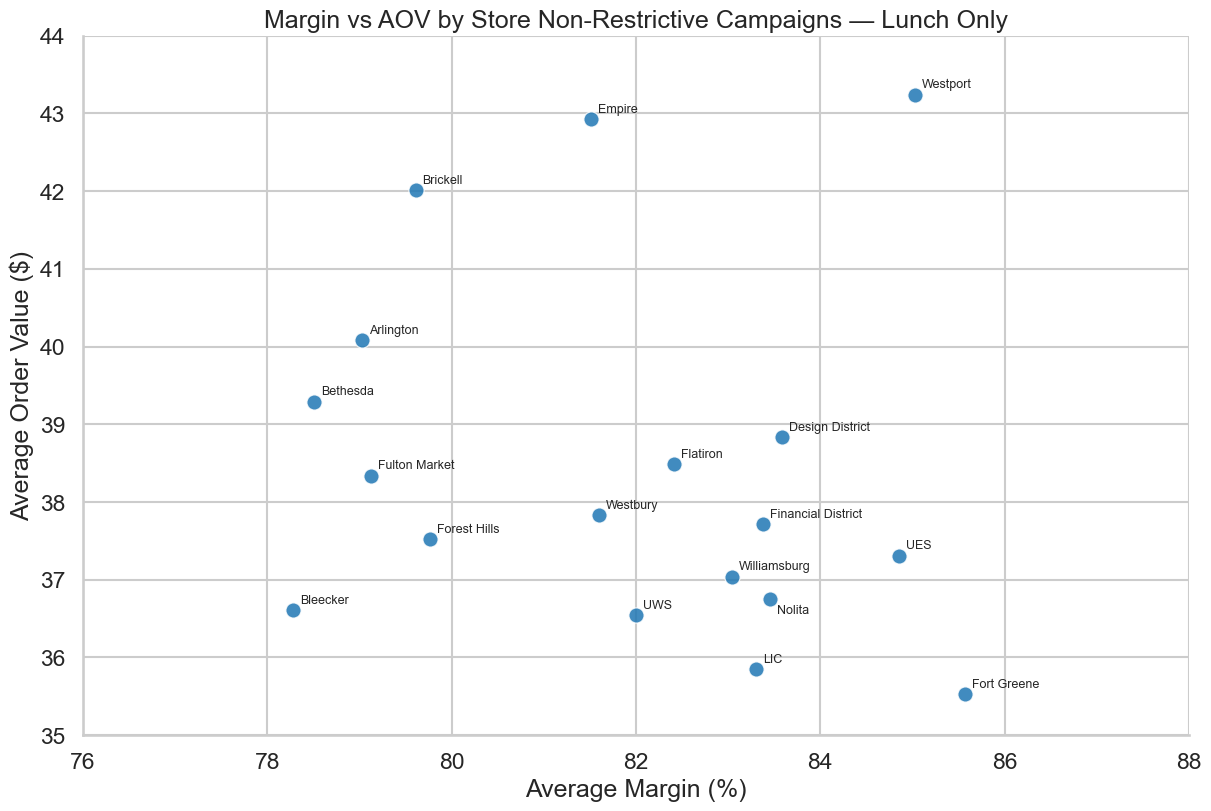

In [28]:
filtered = sales_data[
    (sales_data["Non-Restrictive"] == 1) &
    (sales_data["Day Part"] == "Lunch")
]

store_metrics = (
    filtered
    .groupby("Store Name", as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
)

store_metrics["avg_margin_pct"] = store_metrics["avg_margin"] * 100
store_metrics[["aov", "avg_margin_pct"]] = store_metrics[
    ["aov", "avg_margin_pct"]
].round(2)

# Plot
plt.figure(figsize=(12, 8), constrained_layout=True)

ax = sns.scatterplot(
    data=store_metrics,
    x="avg_margin_pct",
    y="aov",
    color="#1F77B4" ,   
    s=120,
    alpha=0.85
)


for _, row in store_metrics.iterrows():
    ax.annotate(
        row["Store Name"],
        (row["avg_margin_pct"], row["aov"]),
        xytext=(5, -10) if (row["Store Name"] == "Nolita") else (5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Margin vs AOV by Store Non-Restrictive Campaigns — Lunch Only")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")
plt.xlim(76, 88)
plt.ylim(35, 44)
plt.show()

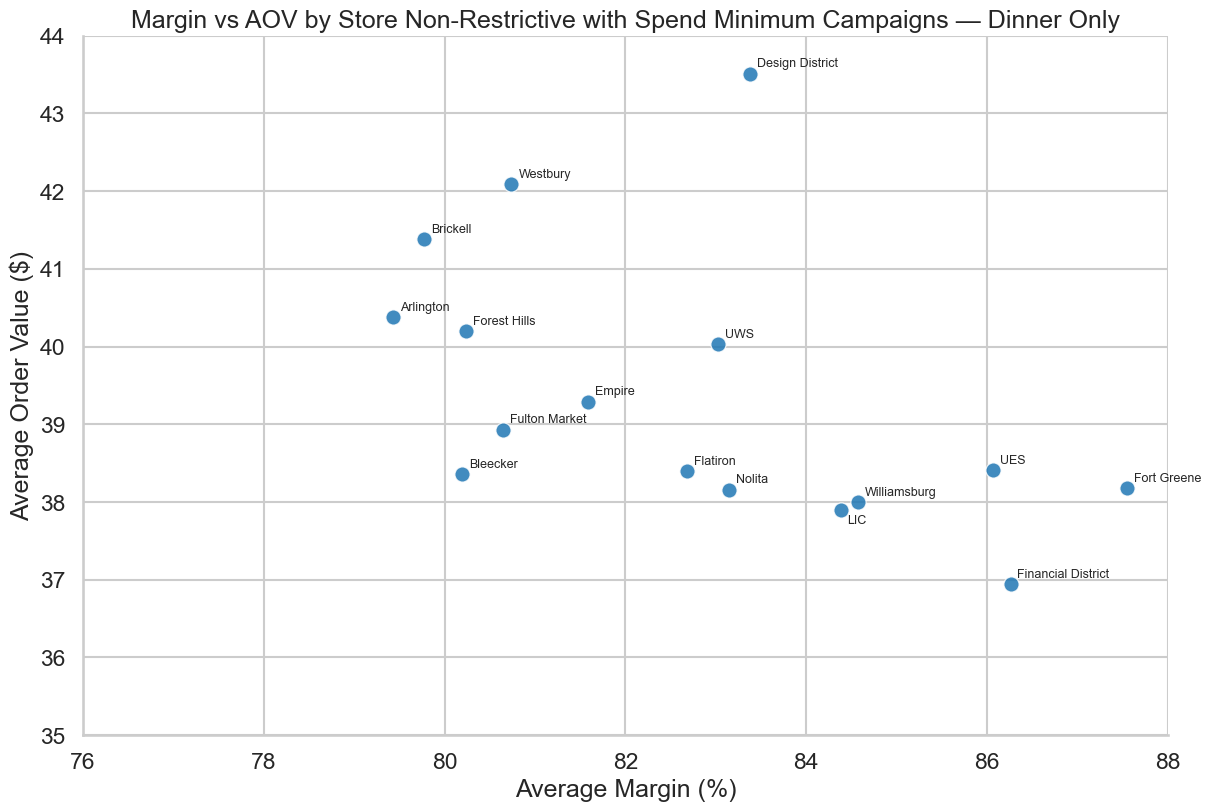

In [29]:
filtered = sales_data[
    (sales_data["Non-Restrictive with Spend Minimum"] == 1) &
    (sales_data["Day Part"] == "Dinner")
]


store_metrics = (
    filtered
    .groupby("Store Name", as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
)

store_metrics["avg_margin_pct"] = store_metrics["avg_margin"] * 100
store_metrics[["aov", "avg_margin_pct"]] = store_metrics[
    ["aov", "avg_margin_pct"]
].round(2)


plt.figure(figsize=(12, 8), constrained_layout=True)

ax = sns.scatterplot(
    data=store_metrics,
    x="avg_margin_pct",
    y="aov",
    color="#1F77B4",  
    s=120,
    alpha=0.85
)


for _, row in store_metrics.iterrows():
    ax.annotate(
        row["Store Name"],
        (row["avg_margin_pct"], row["aov"]),
        xytext=(5, -10) if (row["Store Name"] == "LIC") else (5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Margin vs AOV by Store Non-Restrictive with Spend Minimum Campaigns — Dinner Only")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")
plt.xlim(76, 88)
plt.ylim(35, 44)
plt.show()

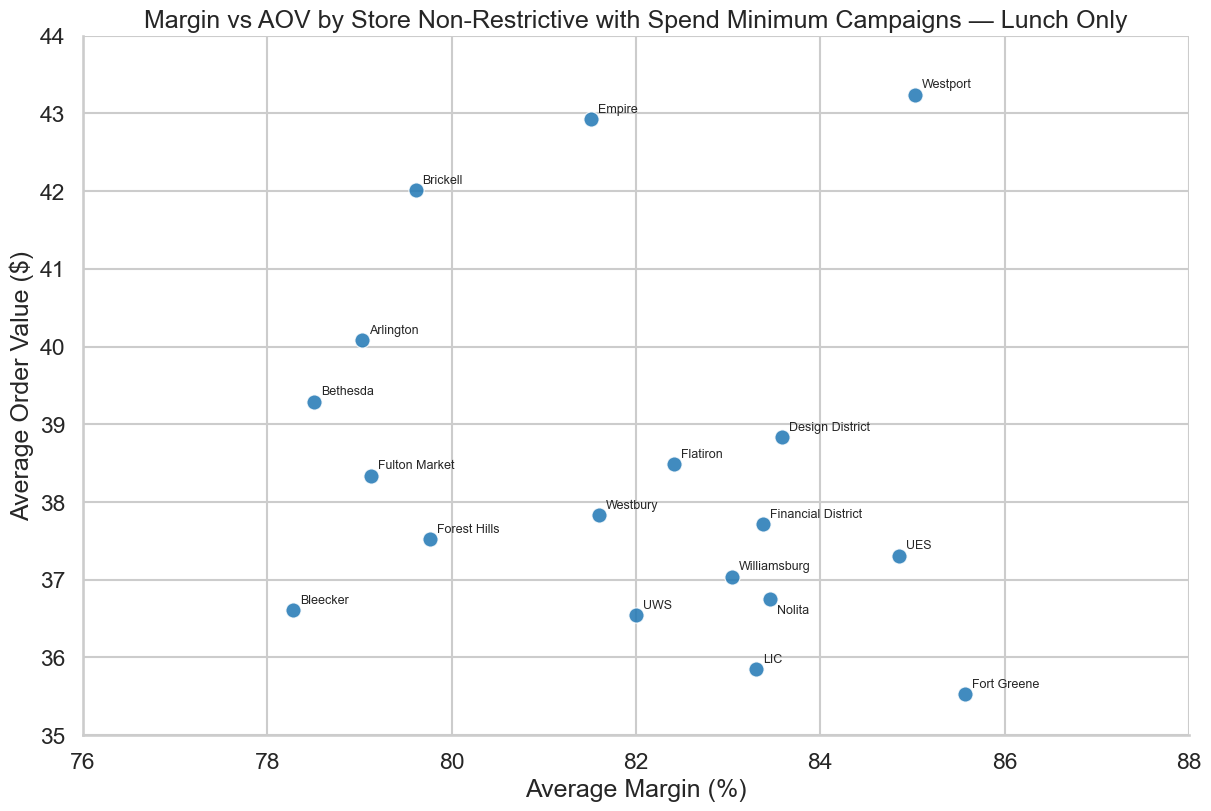

,Store Name,aov,avg_margin,avg_margin_pct
0,Arlington,40.08,0.790314,79.03
1,Bethesda,39.29,0.785147,78.51
2,Bleecker,36.61,0.782781,78.28
3,Brickell,42.01,0.796089,79.61
4,Design District,38.83,0.835930,83.59
5,Empire,42.93,0.815138,81.51
6,Financial District,37.71,0.833827,83.38
7,Flatiron,38.49,0.824079,82.41
8,Forest Hills,37.52,0.797657,79.77
9,Fort Greene,35.53,0.855746,85.57


In [30]:
filtered = sales_data[
    (sales_data["Non-Restrictive with Spend Minimum"] == 1) &
    (sales_data["Day Part"] == "Lunch")
]

store_metrics = (
    filtered
    .groupby("Store Name", as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
)

store_metrics["avg_margin_pct"] = store_metrics["avg_margin"] * 100
store_metrics[["aov", "avg_margin_pct"]] = store_metrics[
    ["aov", "avg_margin_pct"]
].round(2)

# Plot
plt.figure(figsize=(12, 8), constrained_layout=True)

ax = sns.scatterplot(
    data=store_metrics,
    x="avg_margin_pct",
    y="aov",
    color="#1F77B4" ,   
    s=120,
    alpha=0.85
)


for _, row in store_metrics.iterrows():
    ax.annotate(
        row["Store Name"],
        (row["avg_margin_pct"], row["aov"]),
        xytext=(5, -10) if (row["Store Name"] == "Nolita") else (5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Margin vs AOV by Store Non-Restrictive with Spend Minimum Campaigns — Lunch Only")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")
plt.xlim(76, 88)
plt.ylim(35, 44)
plt.show()
store_metrics

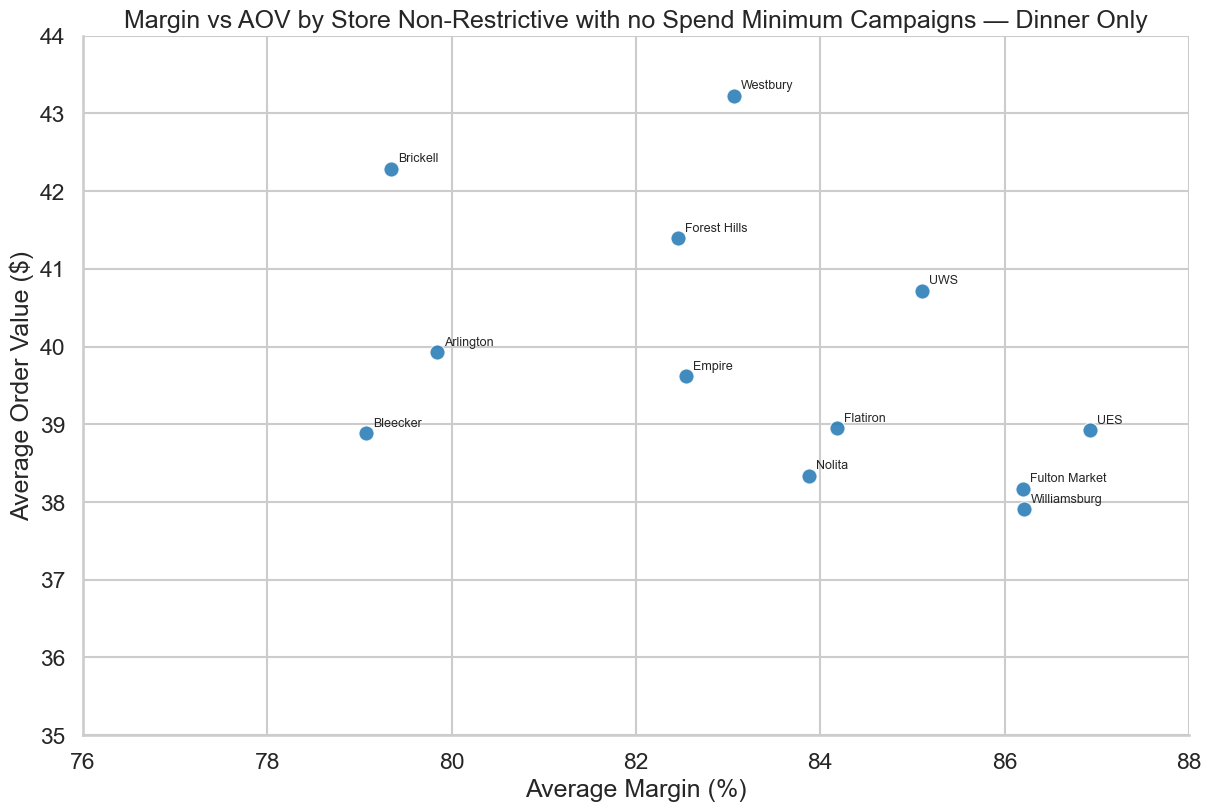

In [31]:
filtered = sales_data[
    (sales_data["Non-Restrictive with no Spend Minimum"] == 1) &
    (sales_data["Day Part"] == "Dinner")
]


store_metrics = (
    filtered
    .groupby("Store Name", as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
)

store_metrics["avg_margin_pct"] = store_metrics["avg_margin"] * 100
store_metrics[["aov", "avg_margin_pct"]] = store_metrics[
    ["aov", "avg_margin_pct"]
].round(2)


plt.figure(figsize=(12, 8), constrained_layout=True)

ax = sns.scatterplot(
    data=store_metrics,
    x="avg_margin_pct",
    y="aov",
    color="#1F77B4",  
    s=120,
    alpha=0.85
)


for _, row in store_metrics.iterrows():
    ax.annotate(
        row["Store Name"],
        (row["avg_margin_pct"], row["aov"]),
        xytext=(5, -10) if (row["Store Name"] == "LIC") else (5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Margin vs AOV by Store Non-Restrictive with no Spend Minimum Campaigns — Dinner Only")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")
plt.xlim(76, 88)
plt.ylim(35, 44)
plt.show()

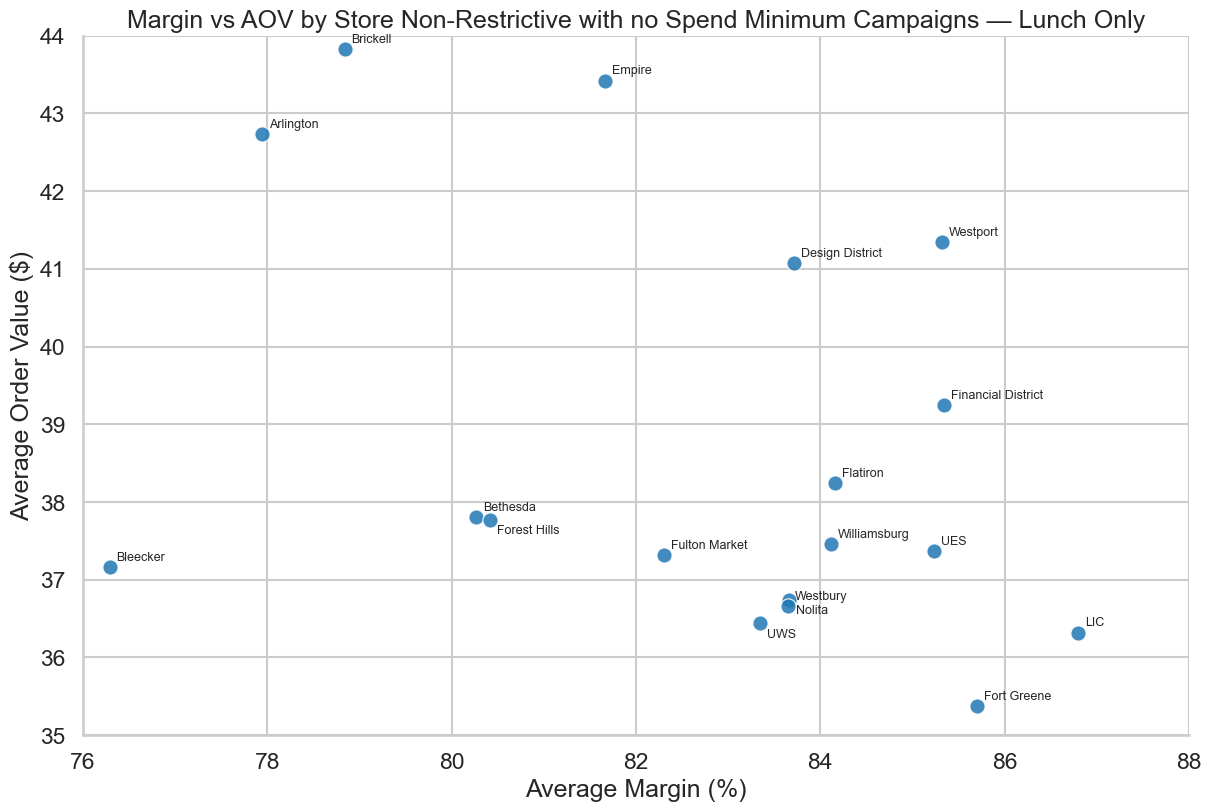

In [32]:
filtered = sales_data[
    (sales_data["Non-Restrictive with no Spend Minimum"] == 1) &
    (sales_data["Day Part"] == "Lunch")
]

store_metrics = (
    filtered
    .groupby("Store Name", as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
)

store_metrics["avg_margin_pct"] = store_metrics["avg_margin"] * 100
store_metrics[["aov", "avg_margin_pct"]] = store_metrics[
    ["aov", "avg_margin_pct"]
].round(2)

# Plot
plt.figure(figsize=(12, 8), constrained_layout=True)

ax = sns.scatterplot(
    data=store_metrics,
    x="avg_margin_pct",
    y="aov",
    color="#1F77B4" ,   
    s=120,
    alpha=0.85
)


for _, row in store_metrics.iterrows():
    ax.annotate(
        row["Store Name"],
        (row["avg_margin_pct"], row["aov"]),
        xytext=(5, -10) if (row["Store Name"] == "Nolita" or row["Store Name"] == "Forest Hills" or row["Store Name"] == "UWS") else (5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Margin vs AOV by Store Non-Restrictive with no Spend Minimum Campaigns — Lunch Only")
plt.xlabel("Average Margin (%)")
plt.ylabel("Average Order Value ($)")
plt.xlim(76, 88)
plt.ylim(35, 44)
plt.show()

In [33]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

In [34]:


summary = (
    sales_data
    .groupby("DayOfWeek")
    .agg(
        orders=("Sales (excl. tax)", "count"),
        promo_orders=("Promo", "sum"),
        total_sales=("Sales (excl. tax)", "sum"),
        promo_sales=("Sales (excl. tax)", lambda x: x[sales_data.loc[x.index, "Promo"] == 1].sum()),
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
    .reset_index()
)

summary["DayOfWeek"] = pd.Categorical(
    summary["DayOfWeek"],
    categories=day_order,
    ordered=True
)

summary = summary.sort_values("DayOfWeek")

summary["promo_pct_orders"] = summary["promo_orders"] / summary["orders"]
summary["promo_pct_dollars"] = summary["promo_sales"] / summary["total_sales"]

summary["aov"] = summary["aov"].round(2)
summary["margin_pct"] = (summary["avg_margin"] * 100).round(2)
summary["promo_pct_orders"] = (summary["promo_pct_orders"] * 100).round(2)
summary["promo_pct_dollars"] = (summary["promo_pct_dollars"] * 100).round(2)

final_table = summary[[
    "DayOfWeek",
    "aov",
    "margin_pct",
    "promo_pct_orders",
    "promo_pct_dollars"
]].rename(columns={
    "aov": "AOV ($)",
    "margin_pct": "Margin %",
    "promo_pct_orders": "Promo % (Orders)",
    "promo_pct_dollars": "Promo % (Dollars)"
})

print("\t\t    Margin vs AOV by Day of Week")
final_table

		    Margin vs AOV by Day of Week


,DayOfWeek,AOV ($),Margin %,Promo % (Orders),Promo % (Dollars)
1,Monday,37.05,86.40,42.96,51.80
5,Tuesday,38.04,86.54,40.82,49.63
6,Wednesday,37.15,88.25,37.82,45.83
4,Thursday,37.41,87.37,40.73,49.32
0,Friday,39.75,85.15,46.07,54.00
2,Saturday,40.23,83.99,48.81,56.42
3,Sunday,39.59,83.49,50.62,58.41


In [35]:
summary = (
    sales_data
    .loc[sales_data["Day Part"] == "Dinner"]
    .groupby("DayOfWeek")
    .agg(
        orders=("Sales (excl. tax)", "count"),
        promo_orders=("Promo", "sum"),
        total_sales=("Sales (excl. tax)", "sum"),
        promo_sales=("Sales (excl. tax)", lambda x: x[sales_data.loc[x.index, "Promo"] == 1].sum()),
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
    .reset_index()
)

summary["DayOfWeek"] = pd.Categorical(
    summary["DayOfWeek"],
    categories=day_order,
    ordered=True
)

summary = summary.sort_values("DayOfWeek")

summary["promo_pct_orders"] = summary["promo_orders"] / summary["orders"]
summary["promo_pct_dollars"] = summary["promo_sales"] / summary["total_sales"]

summary["aov"] = summary["aov"].round(2)
summary["margin_pct"] = (summary["avg_margin"] * 100).round(2)
summary["promo_pct_orders"] = (summary["promo_pct_orders"] * 100).round(2)
summary["promo_pct_dollars"] = (summary["promo_pct_dollars"] * 100).round(2)

final_table = summary[[
    "DayOfWeek",
    "aov",
    "margin_pct",
    "promo_pct_orders",
    "promo_pct_dollars"
]].rename(columns={
    "aov": "AOV ($)",
    "margin_pct": "Margin %",
    "promo_pct_orders": "Promo % (Orders)",
    "promo_pct_dollars": "Promo % (Dollars)"
})

print("\t\tMargin vs AOV by Day of Week - Dinner")
final_table
summary

		Margin vs AOV by Day of Week - Dinner


,DayOfWeek,orders,promo_orders,total_sales,promo_sales,aov,avg_margin,promo_pct_orders,promo_pct_dollars,margin_pct
1,Monday,18071,7817,683182.38,353179.16,37.81,0.866235,43.26,51.70,86.62
5,Tuesday,19813,8099,747574.42,367034.56,37.73,0.867589,40.88,49.10,86.76
6,Wednesday,19266,7287,719731.80,327077.49,37.36,0.884590,37.82,45.44,88.46
4,Thursday,21267,8822,802384.88,397887.25,37.73,0.873650,41.48,49.59,87.37
0,Friday,21798,10145,895169.23,484667.31,41.07,0.854471,46.54,54.14,85.45
2,Saturday,19288,9343,794040.66,441949.88,41.17,0.843262,48.44,55.66,84.33
3,Sunday,19754,10005,791517.43,462112.00,40.07,0.836501,50.65,58.38,83.65


In [36]:
summary = (
    sales_data
    .loc[sales_data["Day Part"] == "Lunch"]
    .groupby("DayOfWeek")
    .agg(
        orders=("Sales (excl. tax)", "count"),
        promo_orders=("Promo", "sum"),
        total_sales=("Sales (excl. tax)", "sum"),
        promo_sales=("Sales (excl. tax)", lambda x: x[sales_data.loc[x.index, "Promo"] == 1].sum()),
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
    .reset_index()
)


summary["DayOfWeek"] = pd.Categorical(
    summary["DayOfWeek"],
    categories=day_order,
    ordered=True
)

summary = summary.sort_values("DayOfWeek")

summary["promo_pct_orders"] = summary["promo_orders"] / summary["orders"]
summary["promo_pct_dollars"] = summary["promo_sales"] / summary["total_sales"]

summary["aov"] = summary["aov"].round(2)
summary["margin_pct"] = (summary["avg_margin"] * 100).round(2)
summary["promo_pct_orders"] = (summary["promo_pct_orders"] * 100).round(2)
summary["promo_pct_dollars"] = (summary["promo_pct_dollars"] * 100).round(2)

final_table = summary[[
    "DayOfWeek",
    "aov",
    "margin_pct",
    "promo_pct_orders",
    "promo_pct_dollars"
]].rename(columns={
    "aov": "AOV ($)",
    "margin_pct": "Margin %",
    "promo_pct_orders": "Promo % (Orders)",
    "promo_pct_dollars": "Promo % (Dollars)"
})

print("\t\tMargin vs AOV by Day of Week - Lunch")
final_table

		Margin vs AOV by Day of Week - Lunch


,DayOfWeek,AOV ($),Margin %,Promo % (Orders),Promo % (Dollars)
1,Monday,35.46,85.93,42.33,52.05
5,Tuesday,38.72,86.07,40.71,50.77
6,Wednesday,36.70,87.78,37.81,46.70
4,Thursday,36.70,87.38,39.04,48.71
0,Friday,37.23,84.58,45.18,53.70
2,Saturday,38.42,83.34,49.52,58.02
3,Sunday,38.72,83.19,50.58,58.46


In [37]:


summary = (
    sales_data
    .loc[(sales_data["Day Part"]== "Dinner") & (sales_data["Restrictive"] == 1)]
    .groupby("DayOfWeek")
    .agg(
        orders=("Sales (excl. tax)", "count"),
        promo_orders=("Promo", "sum"),
        total_sales=("Sales (excl. tax)", "sum"),
        promo_sales=("Sales (excl. tax)", lambda x: x[sales_data.loc[x.index, "Promo"] == 1].sum()),
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
    .reset_index()
)

summary["DayOfWeek"] = pd.Categorical(
    summary["DayOfWeek"],
    categories=day_order,
    ordered=True
)

summary = summary.sort_values("DayOfWeek")

summary["promo_pct_orders"] = summary["promo_orders"] / summary["orders"]
summary["promo_pct_dollars"] = summary["promo_sales"] / summary["total_sales"]

summary["aov"] = summary["aov"].round(2)
summary["margin_pct"] = (summary["avg_margin"] * 100).round(2)
summary["promo_pct_orders"] = (summary["promo_pct_orders"] * 100).round(2)
summary["promo_pct_dollars"] = (summary["promo_pct_dollars"] * 100).round(2)

final_table = summary[[
    "DayOfWeek",
    "aov",
    "margin_pct",
    "promo_pct_orders",
    "promo_pct_dollars"
]].rename(columns={
    "aov": "AOV ($)",
    "margin_pct": "Margin %",
    "promo_pct_orders": "Promo % (Orders)",
    "promo_pct_dollars": "Promo % (Dollars)"
})

print("\tMargin vs AOV by Day of Week - Restrictive Dinner")
final_table
summary

	Margin vs AOV by Day of Week - Restrictive Dinner


,DayOfWeek,orders,promo_orders,total_sales,promo_sales,aov,avg_margin,promo_pct_orders,promo_pct_dollars,margin_pct
1,Monday,15705,7817,598603.03,353179.16,38.12,0.846083,49.77,59.00,84.61
5,Tuesday,17471,8099,664245.83,367034.56,38.02,0.849839,46.36,55.26,84.98
6,Wednesday,16634,7287,624921.45,327077.49,37.57,0.866329,43.81,52.34,86.63
4,Thursday,18466,8822,701416.34,397887.25,37.98,0.854485,47.77,56.73,85.45
0,Friday,18608,10145,769423.43,484667.31,41.35,0.829523,54.52,62.99,82.95
2,Saturday,16612,9343,688393.19,441949.88,41.44,0.818012,56.24,64.20,81.80
3,Sunday,17222,10005,694161.71,462112.00,40.31,0.812463,58.09,66.57,81.25


In [38]:

summary = (
    sales_data
    .loc[(sales_data["Day Part"]== "Lunch") & (sales_data["Restrictive"] == 1)]
    .groupby("DayOfWeek")
    .agg(
        orders=("Sales (excl. tax)", "count"),
        promo_orders=("Promo", "sum"),
        total_sales=("Sales (excl. tax)", "sum"),
        promo_sales=("Sales (excl. tax)", lambda x: x[sales_data.loc[x.index, "Promo"] == 1].sum()),
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
    .reset_index()
)

summary["DayOfWeek"] = pd.Categorical(
    summary["DayOfWeek"],
    categories=day_order,
    ordered=True
)

summary = summary.sort_values("DayOfWeek")

summary["promo_pct_orders"] = summary["promo_orders"] / summary["orders"]
summary["promo_pct_dollars"] = summary["promo_sales"] / summary["total_sales"]

summary["aov"] = summary["aov"].round(2)
summary["margin_pct"] = (summary["avg_margin"] * 100).round(2)
summary["promo_pct_orders"] = (summary["promo_pct_orders"] * 100).round(2)
summary["promo_pct_dollars"] = (summary["promo_pct_dollars"] * 100).round(2)

final_table = summary[[
    "DayOfWeek",
    "aov",
    "margin_pct",
    "promo_pct_orders",
    "promo_pct_dollars"
]].rename(columns={
    "aov": "AOV ($)",
    "margin_pct": "Margin %",
    "promo_pct_orders": "Promo % (Orders)",
    "promo_pct_dollars": "Promo % (Dollars)"
})

print("\t   Margin vs AOV by Day of Week - Restrictive Lunch")
final_table

	   Margin vs AOV by Day of Week - Restrictive Lunch


,DayOfWeek,AOV ($),Margin %,Promo % (Orders),Promo % (Dollars)
1,Monday,35.87,83.71,49.04,59.60
5,Tuesday,38.99,84.11,46.41,57.46
6,Wednesday,36.79,85.60,44.56,54.89
4,Thursday,36.97,85.15,45.94,56.90
0,Friday,37.61,82.04,52.64,61.94
2,Saturday,39.02,80.42,58.21,67.15
3,Sunday,39.23,80.31,59.24,67.59


In [39]:

summary = (
    sales_data
    .loc[(sales_data["Day Part"]== "Dinner") & (sales_data["Non-Restrictive"] == 1)]
    .groupby("DayOfWeek")
    .agg(
        orders=("Sales (excl. tax)", "count"),
        promo_orders=("Promo", "sum"),
        total_sales=("Sales (excl. tax)", "sum"),
        promo_sales=("Sales (excl. tax)", lambda x: x[sales_data.loc[x.index, "Promo"] == 1].sum()),
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
    .reset_index()
)

summary["DayOfWeek"] = pd.Categorical(
    summary["DayOfWeek"],
    categories=day_order,
    ordered=True
)

summary = summary.sort_values("DayOfWeek")

summary["promo_pct_orders"] = summary["promo_orders"] / summary["orders"]
summary["promo_pct_dollars"] = summary["promo_sales"] / summary["total_sales"]

summary["aov"] = summary["aov"].round(2)
summary["margin_pct"] = (summary["avg_margin"] * 100).round(2)
summary["promo_pct_orders"] = (summary["promo_pct_orders"] * 100).round(2)
summary["promo_pct_dollars"] = (summary["promo_pct_dollars"] * 100).round(2)

final_table = summary[[
    "DayOfWeek",
    "aov",
    "margin_pct",
    "promo_pct_orders",
    "promo_pct_dollars"
]].rename(columns={
    "aov": "AOV ($)",
    "margin_pct": "Margin %",
    "promo_pct_orders": "Promo % (Orders)",
    "promo_pct_dollars": "Promo % (Dollars)"
})

print("\tMargin vs AOV by Day of Week - Non-Restrictive Dinner")
final_table

	Margin vs AOV by Day of Week - Non-Restrictive Dinner


,DayOfWeek,AOV ($),Margin %,Promo % (Orders),Promo % (Dollars)
1,Monday,38.26,84.22,50.84,60.62
5,Tuesday,38.17,84.45,47.44,57.06
6,Wednesday,37.71,86.36,44.48,53.53
4,Thursday,37.99,85.01,49.02,58.53
0,Friday,41.57,82.10,56.76,65.69
2,Saturday,41.53,81.07,58.03,66.67
3,Sunday,40.45,80.42,60.07,68.88


In [40]:

summary = (
    sales_data
    .loc[(sales_data["Day Part"]== "Lunch") & (sales_data["Non-Restrictive"] == 1)]
    .groupby("DayOfWeek")
    .agg(
        orders=("Sales (excl. tax)", "count"),
        promo_orders=("Promo", "sum"),
        total_sales=("Sales (excl. tax)", "sum"),
        promo_sales=("Sales (excl. tax)", lambda x: x[sales_data.loc[x.index, "Promo"] == 1].sum()),
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
    .reset_index()
)

summary["DayOfWeek"] = pd.Categorical(
    summary["DayOfWeek"],
    categories=day_order,
    ordered=True
)

summary = summary.sort_values("DayOfWeek")

summary["promo_pct_orders"] = summary["promo_orders"] / summary["orders"]
summary["promo_pct_dollars"] = summary["promo_sales"] / summary["total_sales"]

summary["aov"] = summary["aov"].round(2)
summary["margin_pct"] = (summary["avg_margin"] * 100).round(2)
summary["promo_pct_orders"] = (summary["promo_pct_orders"] * 100).round(2)
summary["promo_pct_dollars"] = (summary["promo_pct_dollars"] * 100).round(2)

final_table = summary[[
    "DayOfWeek",
    "aov",
    "margin_pct",
    "promo_pct_orders",
    "promo_pct_dollars"
]].rename(columns={
    "aov": "AOV ($)",
    "margin_pct": "Margin %",
    "promo_pct_orders": "Promo % (Orders)",
    "promo_pct_dollars": "Promo % (Dollars)"
})

print("\tMargin vs AOV by Day of Week - Non-Restrictive Lunch")
final_table

	Margin vs AOV by Day of Week - Non-Restrictive Lunch


,DayOfWeek,AOV ($),Margin %,Promo % (Orders),Promo % (Dollars)
1,Monday,36.15,83.29,50.25,61.57
5,Tuesday,39.48,83.70,47.57,59.71
6,Wednesday,37.21,85.39,45.38,56.54
4,Thursday,37.25,84.82,47.10,59.09
0,Friday,37.76,81.27,54.51,64.69
2,Saturday,39.28,79.61,60.20,69.64
3,Sunday,39.39,79.40,61.54,70.36


In [41]:

summary = (
    sales_data
    .loc[(sales_data["Day Part"]== "Dinner") & (sales_data["Non-Restrictive with Spend Minimum"] == 1)]
    .groupby("DayOfWeek")
    .agg(
        orders=("Sales (excl. tax)", "count"),
        promo_orders=("Promo", "sum"),
        total_sales=("Sales (excl. tax)", "sum"),
        promo_sales=("Sales (excl. tax)", lambda x: x[sales_data.loc[x.index, "Promo"] == 1].sum()),
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
    .reset_index()
)

summary["DayOfWeek"] = pd.Categorical(
    summary["DayOfWeek"],
    categories=day_order,
    ordered=True
)

summary = summary.sort_values("DayOfWeek")

summary["promo_pct_orders"] = summary["promo_orders"] / summary["orders"]
summary["promo_pct_dollars"] = summary["promo_sales"] / summary["total_sales"]

summary["aov"] = summary["aov"].round(2)
summary["margin_pct"] = (summary["avg_margin"] * 100).round(2)
summary["promo_pct_orders"] = (summary["promo_pct_orders"] * 100).round(2)
summary["promo_pct_dollars"] = (summary["promo_pct_dollars"] * 100).round(2)

final_table = summary[[
    "DayOfWeek",
    "aov",
    "margin_pct",
    "promo_pct_orders",
    "promo_pct_dollars"
]].rename(columns={
    "aov": "AOV ($)",
    "margin_pct": "Margin %",
    "promo_pct_orders": "Promo % (Orders)",
    "promo_pct_dollars": "Promo % (Dollars)"
})

print("Margin vs AOV by Day of Week - Non-Restrictive with Spend Minimum Dinner")
final_table

Margin vs AOV by Day of Week - Non-Restrictive with Spend Minimum Dinner


,DayOfWeek,AOV ($),Margin %,Promo % (Orders),Promo % (Dollars)
1,Monday,38.26,84.22,50.84,60.62
5,Tuesday,38.17,84.45,47.44,57.06
6,Wednesday,37.71,86.36,44.48,53.53
4,Thursday,37.99,85.01,49.02,58.53
0,Friday,41.57,82.10,56.76,65.69
2,Saturday,41.53,81.07,58.03,66.67
3,Sunday,40.45,80.42,60.07,68.88


In [42]:


summary = (
    sales_data
    .loc[(sales_data["Day Part"]== "Lunch") & (sales_data["Non-Restrictive with Spend Minimum"] == 1)]
    .groupby("DayOfWeek")
    .agg(
        orders=("Sales (excl. tax)", "count"),
        promo_orders=("Promo", "sum"),
        total_sales=("Sales (excl. tax)", "sum"),
        promo_sales=("Sales (excl. tax)", lambda x: x[sales_data.loc[x.index, "Promo"] == 1].sum()),
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
    .reset_index()
)

summary["DayOfWeek"] = pd.Categorical(
    summary["DayOfWeek"],
    categories=day_order,
    ordered=True
)

summary = summary.sort_values("DayOfWeek")

summary["promo_pct_orders"] = summary["promo_orders"] / summary["orders"]
summary["promo_pct_dollars"] = summary["promo_sales"] / summary["total_sales"]

summary["aov"] = summary["aov"].round(2)
summary["margin_pct"] = (summary["avg_margin"] * 100).round(2)
summary["promo_pct_orders"] = (summary["promo_pct_orders"] * 100).round(2)
summary["promo_pct_dollars"] = (summary["promo_pct_dollars"] * 100).round(2)

final_table = summary[[
    "DayOfWeek",
    "aov",
    "margin_pct",
    "promo_pct_orders",
    "promo_pct_dollars"
]].rename(columns={
    "aov": "AOV ($)",
    "margin_pct": "Margin %",
    "promo_pct_orders": "Promo % (Orders)",
    "promo_pct_dollars": "Promo % (Dollars)"
})

print("Margin vs AOV by Day of Week - Non-Restrictive with Spend Minimum Lunch")
final_table

Margin vs AOV by Day of Week - Non-Restrictive with Spend Minimum Lunch


,DayOfWeek,AOV ($),Margin %,Promo % (Orders),Promo % (Dollars)
1,Monday,36.15,83.29,50.25,61.57
5,Tuesday,39.48,83.70,47.57,59.71
6,Wednesday,37.21,85.39,45.38,56.54
4,Thursday,37.25,84.82,47.10,59.09
0,Friday,37.76,81.27,54.51,64.69
2,Saturday,39.28,79.61,60.20,69.64
3,Sunday,39.39,79.40,61.54,70.36


In [43]:


summary = (
    sales_data
    .loc[(sales_data["Day Part"]== "Dinner") & (sales_data["Non-Restrictive with no Spend Minimum"] == 1)]
    .groupby("DayOfWeek")
    .agg(
        orders=("Sales (excl. tax)", "count"),
        promo_orders=("Promo", "sum"),
        total_sales=("Sales (excl. tax)", "sum"),
        promo_sales=("Sales (excl. tax)", lambda x: x[sales_data.loc[x.index, "Promo"] == 1].sum()),
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
    .reset_index()
)

summary["DayOfWeek"] = pd.Categorical(
    summary["DayOfWeek"],
    categories=day_order,
    ordered=True
)

summary = summary.sort_values("DayOfWeek")

summary["promo_pct_orders"] = summary["promo_orders"] / summary["orders"]
summary["promo_pct_dollars"] = summary["promo_sales"] / summary["total_sales"]

summary["aov"] = summary["aov"].round(2)
summary["margin_pct"] = (summary["avg_margin"] * 100).round(2)
summary["promo_pct_orders"] = (summary["promo_pct_orders"] * 100).round(2)
summary["promo_pct_dollars"] = (summary["promo_pct_dollars"] * 100).round(2)

final_table = summary[[
    "DayOfWeek",
    "aov",
    "margin_pct",
    "promo_pct_orders",
    "promo_pct_dollars"
]].rename(columns={
    "aov": "AOV ($)",
    "margin_pct": "Margin %",
    "promo_pct_orders": "Promo % (Orders)",
    "promo_pct_dollars": "Promo % (Dollars)"
})

print("Margin vs AOV by Day of Week - Non-Restrictive with no Spend Minimum Dinner")
final_table

Margin vs AOV by Day of Week - Non-Restrictive with no Spend Minimum Dinner


,DayOfWeek,AOV ($),Margin %,Promo % (Orders),Promo % (Dollars)
1,Monday,38.20,85.40,40.30,48.16
5,Tuesday,38.28,84.94,42.13,51.31
6,Wednesday,38.13,87.30,36.69,44.52
4,Thursday,38.41,85.54,41.10,49.25
0,Friday,42.14,83.21,47.84,56.49
2,Saturday,41.73,83.80,45.47,53.32
3,Sunday,40.83,83.66,46.10,54.50


In [44]:

summary = (
    sales_data
    .loc[(sales_data["Day Part"]== "Lunch") & (sales_data["Non-Restrictive with no Spend Minimum"] == 1)]
    .groupby("DayOfWeek")
    .agg(
        orders=("Sales (excl. tax)", "count"),
        promo_orders=("Promo", "sum"),
        total_sales=("Sales (excl. tax)", "sum"),
        promo_sales=("Sales (excl. tax)", lambda x: x[sales_data.loc[x.index, "Promo"] == 1].sum()),
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean")
    )
    .reset_index()
)

summary["DayOfWeek"] = pd.Categorical(
    summary["DayOfWeek"],
    categories=day_order,
    ordered=True
)

summary = summary.sort_values("DayOfWeek")

summary["promo_pct_orders"] = summary["promo_orders"] / summary["orders"]
summary["promo_pct_dollars"] = summary["promo_sales"] / summary["total_sales"]

summary["aov"] = summary["aov"].round(2)
summary["margin_pct"] = (summary["avg_margin"] * 100).round(2)
summary["promo_pct_orders"] = (summary["promo_pct_orders"] * 100).round(2)
summary["promo_pct_dollars"] = (summary["promo_pct_dollars"] * 100).round(2)

final_table = summary[[
    "DayOfWeek",
    "aov",
    "margin_pct",
    "promo_pct_orders",
    "promo_pct_dollars"
]].rename(columns={
    "aov": "AOV ($)",
    "margin_pct": "Margin %",
    "promo_pct_orders": "Promo % (Orders)",
    "promo_pct_dollars": "Promo % (Dollars)"
})

print("Margin vs AOV by Day of Week - Non-Restrictive with no Spend Minimum Lunch")
final_table

Margin vs AOV by Day of Week - Non-Restrictive with no Spend Minimum Lunch


,DayOfWeek,AOV ($),Margin %,Promo % (Orders),Promo % (Dollars)
1,Monday,36.09,83.00,47.17,55.69
5,Tuesday,39.17,82.53,47.65,57.81
6,Wednesday,37.60,85.73,42.00,52.17
4,Thursday,38.50,85.25,43.55,53.18
0,Friday,38.40,81.70,51.29,60.22
2,Saturday,39.16,82.03,52.60,61.94
3,Sunday,39.80,81.32,53.72,62.43


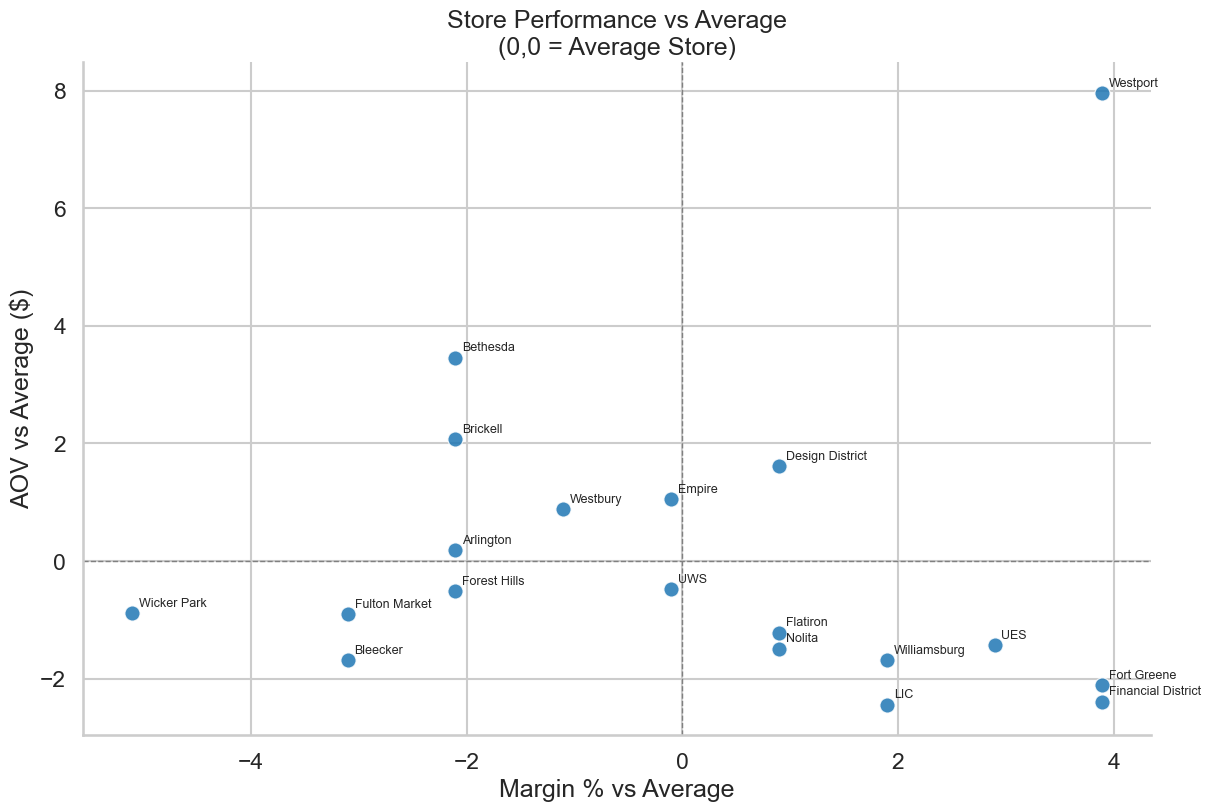

In [45]:
store_metrics = (
    sales_data
    .groupby("Store Name", as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean"),
    )
)

store_metrics[["aov", "avg_margin"]] = store_metrics[["aov", "avg_margin"]].round(2)
store_metrics["avg_margin_pct"] = store_metrics["avg_margin"] * 100

# ---- Compute overall averages ----
avg_aov = store_metrics["aov"].mean()
avg_margin_pct = store_metrics["avg_margin_pct"].mean()

# ---- Convert to deltas ----
store_metrics["delta_aov"] = store_metrics["aov"] - avg_aov
store_metrics["delta_margin_pct"] = store_metrics["avg_margin_pct"] - avg_margin_pct

# ---- Plot ----
plt.figure(figsize=(12, 8), constrained_layout=True)

ax = sns.scatterplot(
    data=store_metrics,
    x="delta_margin_pct",
    y="delta_aov",
    color="#1F77B4",
    s=120,
    alpha=0.85
)

# Reference lines at 0
ax.axhline(0, color="gray", lw=1, linestyle="--")
ax.axvline(0, color="gray", lw=1, linestyle="--")


for _, row in store_metrics.iterrows():
    ax.annotate(
        row["Store Name"],
        (row["delta_margin_pct"], row["delta_aov"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Store Performance vs Average\n(0,0 = Average Store)")
plt.xlabel("Margin % vs Average")
plt.ylabel("AOV vs Average ($)")

plt.show()

In [46]:
print("\t\t\tStore difference from Average Table")
store_metrics.sort_values("delta_aov")


			Store difference from Average Table


,Store Name,aov,avg_margin,avg_margin_pct,delta_aov,delta_margin_pct
11,LIC,36.65,0.87,87.0,-2.439474,1.894737
6,Financial District,36.70,0.89,89.0,-2.389474,3.894737
9,Fort Greene,36.98,0.89,89.0,-2.109474,3.894737
18,Williamsburg,37.40,0.87,87.0,-1.689474,1.894737
2,Bleecker,37.41,0.82,82.0,-1.679474,-3.105263
12,Nolita,37.60,0.86,86.0,-1.489474,0.894737
13,UES,37.66,0.88,88.0,-1.429474,2.894737
7,Flatiron,37.87,0.86,86.0,-1.219474,0.894737
10,Fulton Market,38.19,0.82,82.0,-0.899474,-3.105263
17,Wicker Park,38.20,0.80,80.0,-0.889474,-5.105263


In [ ]:
day_metrics = (
    sales_data
    .groupby(["DayOfWeek", "Day Part"], as_index=False)
    .agg(
        aov=("Sales (excl. tax)", "mean"),
        avg_margin=("Margin %", "mean"),
        orders=("Sales (excl. tax)", "count")
    )
)

day_metrics["avg_margin_pct"] = day_metrics["avg_margin"] * 100
day_metrics["aov"] = day_metrics["aov"].round(4)

day_metrics

,DayOfWeek,Day Part,aov,avg_margin,orders,avg_margin_pct
0,Friday,Dinner,41.0666,0.854471,21798,85.447088
1,Friday,Lunch,37.2347,0.845831,11371,84.583149
2,Monday,Dinner,37.8055,0.866235,18071,86.623480
3,Monday,Lunch,35.4628,0.859332,8617,85.933229
4,Saturday,Dinner,41.1676,0.843262,19288,84.326176
5,Saturday,Lunch,38.4154,0.833388,9890,83.338773
6,Sunday,Dinner,40.0687,0.836501,19754,83.650101
7,Sunday,Lunch,38.7209,0.831873,10890,83.187281
8,Thursday,Dinner,37.7291,0.873650,21267,87.365014
9,Thursday,Lunch,36.7038,0.873779,9484,87.377892


In [58]:
ny_lunch = sales_data[
    (sales_data['State'] == 'New York') &
    (sales_data['Day Part'] == 'Dinner')
]

ny_store_table = (
    ny_lunch
        .groupby('Store Name')
        .agg(
            AOV=('Sales (excl. tax)', 'mean'),
            Margin=('Margin %', 'mean')
        )
        .reset_index()
)

#basket value = AOV * margin
ny_store_table['Basket Value'] = (
    ny_store_table['AOV'] * ny_store_table['Margin']
)

ny_store_table = ny_store_table.sort_values(
    by='Basket Value',
    ascending=False
)
print("New York Stores AOV, Margin, and Basket Value - Dinner")
ny_store_table

New York Stores AOV, Margin, and Basket Value - Dinner


,Store Name,AOV,Margin,Basket Value
10,Westbury,41.872934,0.831643,34.823325
9,UWS,39.637062,0.856388,33.944696
5,Fort Greene,37.800462,0.891231,33.688946
8,UES,38.114250,0.882174,33.623391
1,Empire,38.951352,0.846379,32.967603
4,Forest Hills,39.648571,0.829826,32.901396
11,Williamsburg,37.616539,0.873270,32.849383
6,LIC,37.465067,0.874367,32.758201
3,Flatiron,37.887670,0.860776,32.612808
2,Financial District,36.542880,0.892092,32.599618


In [59]:
ny_lunch = sales_data[
    (sales_data['State'] == 'New York') &
    (sales_data['Day Part'] == 'Lunch')
]

ny_store_table = (
    ny_lunch
        .groupby('Store Name')
        .agg(
            AOV=('Sales (excl. tax)', 'mean'),
            Margin=('Margin %', 'mean')
        )
        .reset_index()
)

#basket value = AOV * margin
ny_store_table['Basket Value'] = (
    ny_store_table['AOV'] * ny_store_table['Margin']
)

ny_store_table = ny_store_table.sort_values(
    by='Basket Value',
    ascending=False
)

print("New York Stores AOV, Margin, and Basket Value - Lunch")
ny_store_table

New York Stores AOV, Margin, and Basket Value - Lunch


,Store Name,AOV,Margin,Basket Value
1,Empire,42.309452,0.844283,35.721142
3,Flatiron,37.826296,0.855914,32.376042
2,Financial District,37.053124,0.868732,32.189253
8,UES,36.503576,0.873347,31.880281
7,Nolita,36.898632,0.861691,31.795217
11,Williamsburg,36.904495,0.859862,31.732774
10,Westbury,36.919454,0.844944,31.194867
5,Fort Greene,35.102561,0.877357,30.797479
4,Forest Hills,36.875056,0.833486,30.734825
9,UWS,36.062440,0.848734,30.607415


In [74]:
ny_data = sales_data[
    (sales_data['State'] == 'New York') & 
    (sales_data['Day Part'].isin(['Lunch', 'Dinner']))
]

agg = (
    ny_data
        .groupby(['Store Name', 'Day Part'])
        .agg(
            AOV=('Sales (excl. tax)', 'mean'),
            Margin=('Margin %', 'mean')
        )
        .reset_index()
)

agg['Basket Value'] = agg['AOV'] * agg['Margin']

ny_store_table = agg.pivot(index='Store Name', columns='Day Part')

ny_store_table.columns = [f"{metric}_{daypart}" for metric, daypart in ny_store_table.columns]
ny_store_table = ny_store_table.reset_index()

cols_to_round = ny_store_table.columns.drop('Store Name')
ny_store_table[cols_to_round] = ny_store_table[cols_to_round].round(2)

def compare_basket(row):
    if row['Basket Value_Lunch'] > row['Basket Value_Dinner']:
        return 'Lunch'
    elif row['Basket Value_Dinner'] > row['Basket Value_Lunch']:
        return 'Dinner'
    else:
        return 'Equal'

ny_store_table['Higher Basket'] = ny_store_table.apply(compare_basket, axis=1)

ny_store_table['Max Basket Value'] = ny_store_table[
    ['Basket Value_Lunch', 'Basket Value_Dinner']
].max(axis=1)

ny_store_table = ny_store_table.sort_values(
    by='Max Basket Value',
    ascending=False
).reset_index(drop=True)


ny_store_table = ny_store_table.drop(columns=['Max Basket Value'])


print("\t\t\t\tNew York Stores AOV, Margin, and Basket Value - Dinner vs Lunch")
ny_store_table

				New York Stores AOV, Margin, and Basket Value - Dinner vs Lunch


,Store Name,AOV_Dinner,AOV_Lunch,Margin_Dinner,Margin_Lunch,Basket Value_Dinner,Basket Value_Lunch,Higher Basket
0,Empire,38.95,42.31,0.85,0.84,32.97,35.72,Lunch
1,Westbury,41.87,36.92,0.83,0.84,34.82,31.19,Dinner
2,UWS,39.64,36.06,0.86,0.85,33.94,30.61,Dinner
3,Fort Greene,37.80,35.10,0.89,0.88,33.69,30.80,Dinner
4,UES,38.11,36.50,0.88,0.87,33.62,31.88,Dinner
5,Forest Hills,39.65,36.88,0.83,0.83,32.90,30.73,Dinner
6,Williamsburg,37.62,36.90,0.87,0.86,32.85,31.73,Dinner
7,LIC,37.47,35.09,0.87,0.87,32.76,30.38,Dinner
8,Flatiron,37.89,37.83,0.86,0.86,32.61,32.38,Dinner
9,Financial District,36.54,37.05,0.89,0.87,32.60,32.19,Dinner
